<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/DCGAN_FMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# Step 1 — Install Required Packages
# ============================================================
# Deskripsi:
# Cell ini memasang library yang diperlukan untuk pipeline penelitian,
# evaluasi model, penyimpanan artefak, serta deployment dashboard Streamlit.
# Perintah ini aman dijalankan di Google Colab. Jika paket sudah tersedia,
# pip hanya akan memastikan dependensi berada pada kondisi yang sesuai.

!pip -q install streamlit pyngrok joblib scikit-learn scipy matplotlib pandas numpy pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.0 MB/s eta 0:00:00


In [5]:
# ============================================================
# Step 2 — Import Libraries, Project Folder, and Configuration
# ============================================================
# Deskripsi:
# Cell ini mengimpor library utama, membuat folder proyek terpadu,
# menetapkan konfigurasi penelitian, serta mengaktifkan kontrol reproducibility.
# Seluruh artefak penelitian akan disimpan dalam satu folder agar proses audit,
# replikasi, dan pelaporan dapat dilakukan secara konsisten.

import os
import json
import math
import time
import random
import shutil
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, utils

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from scipy.linalg import sqrtm
from scipy.spatial.distance import jensenshannon

import joblib

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Konfigurasi utama eksperimen.
# Catatan akademik:
# Nilai konfigurasi ini dibuat ringan karena menggunakan 10% data.
# Untuk eksperimen final, data_fraction dan jumlah epoch dapat dinaikkan.
# ------------------------------------------------------------

CONFIG = {
    "project_title": "DCGAN-FMNIST Research and Deployment Pipeline",
    "seed": 42,
    "data_fraction": 0.10,
    "validation_size": 0.10,
    "batch_size": 128,
    "num_workers": 2,
    "latent_dim": 100,
    "image_size": 28,
    "channels": 1,
    "classifier_epochs": 3,
    "dcgan_epochs": 3,
    "improved_dcgan_epochs": 2,
    "classifier_lr": 1e-3,
    "dcgan_lr_g": 2e-4,
    "dcgan_lr_d": 2e-4,
    "improved_lr_g": 2e-4,
    "improved_lr_d": 1e-4,
    "beta1": 0.5,
    "beta2": 0.999,
    "num_eval_samples": 1000,
    "smoke_test_samples": 7,
    "imbalance_threshold": 1.20,
    "mode_collapse_entropy_threshold": 1.80,
    "dominant_class_threshold": 0.35,
    "fast_run": True
}

# ------------------------------------------------------------
# Folder proyek tunggal.
# Semua data, grafik, model, laporan, dan aplikasi Streamlit
# akan disimpan dalam struktur folder yang sama.
# ------------------------------------------------------------

PROJECT_DIR = Path("dcgan_fmnist_research_deployment")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"
MODEL_DIR = PROJECT_DIR / "models"
REPORT_DIR = PROJECT_DIR / "reports"
APP_DIR = PROJECT_DIR / "streamlit_app"
ERROR_LOG_DIR = PROJECT_DIR / "error_logs"

for directory in [
    PROJECT_DIR,
    DATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    MODEL_DIR,
    REPORT_DIR,
    APP_DIR,
    ERROR_LOG_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Kontrol reproducibility.
# Catatan akademik:
# Reproducibility pada GPU tidak selalu absolut lintas perangkat,
# tetapi seed dan deterministic setting membantu menjaga konsistensi
# proses eksperimen pada lingkungan yang sama.
# ------------------------------------------------------------

def set_global_seed(seed: int = 42) -> None:
    """Mengatur seed global untuk Python, NumPy, dan PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Pengaturan CuDNN untuk mengurangi nondeterminisme.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Generator khusus DataLoader agar shuffle tetap reproducible.
DATALOADER_GENERATOR = torch.Generator()
DATALOADER_GENERATOR.manual_seed(CONFIG["seed"])

# ------------------------------------------------------------
# Simpan konfigurasi agar eksperimen dapat diaudit ulang.
# ------------------------------------------------------------

CONFIG_PATH = OUTPUT_DIR / "experiment_config.json"
with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=4, ensure_ascii=False)

print("Project Initialization Summary")
print("=" * 40)
print(f"Project title      : {CONFIG['project_title']}")
print(f"Project directory  : {PROJECT_DIR.resolve()}")
print(f"Device             : {DEVICE}")
print(f"Seed               : {CONFIG['seed']}")
print(f"Data fraction      : {CONFIG['data_fraction'] * 100:.1f}%")
print(f"Config saved to    : {CONFIG_PATH}")
print("=" * 40)

Project Initialization Summary
Project title      : DCGAN-FMNIST Research and Deployment Pipeline
Project directory  : /content/dcgan_fmnist_research_deployment
Device             : cpu
Seed               : 42
Data fraction      : 10.0%
Config saved to    : dcgan_fmnist_research_deployment/outputs/experiment_config.json


In [6]:
# ============================================================
# Step 3 — Automatic Dataset Loading with Stratified 10% Subset
# ============================================================
# Deskripsi:
# Cell ini memuat dataset Fashion-MNIST secara otomatis dan efisien.
# Dataset hanya diunduh jika belum tersedia di folder cache.
# Setelah itu, program mengambil 10% data secara stratified agar proporsi
# setiap kelas tetap seimbang dan komputasi menjadi lebih ringan.
#
# Prinsip integritas:
# 1. Dataset tidak diunduh berulang-ulang.
# 2. Subset 10% disimpan sebagai indeks cache agar eksperimen dapat direproduksi.
# 3. Split train-validation dilakukan secara stratified untuk mencegah bias kelas.
# 4. Tidak ada metrik performa yang diklaim pada tahap ini.

# ------------------------------------------------------------
# Definisi transformasi data.
# eda_transform dipakai untuk inspeksi data mentah dalam rentang [0, 1].
# train_transform dipakai untuk DCGAN karena generator memakai Tanh,
# sehingga data real harus berada dalam rentang [-1, 1].
# classifier_aug_transform dipakai khusus untuk classifier evaluator
# dengan augmentasi ringan agar generalisasi lebih baik.
# ------------------------------------------------------------

eda_transform = transforms.Compose([
    transforms.ToTensor()
])

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

classifier_aug_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=8,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ------------------------------------------------------------
# Fungsi pengecekan cache Fashion-MNIST.
# Torchvision menyimpan hasil processed dataset pada subfolder:
# FashionMNIST/processed/training.pt dan FashionMNIST/processed/test.pt
# ------------------------------------------------------------

def fashionmnist_processed_exists(root: Path) -> bool:
    """Memeriksa apakah Fashion-MNIST sudah tersedia di cache lokal."""
    processed_dir = root / "FashionMNIST" / "processed"
    expected_files = ["training.pt", "test.pt"]
    return all((processed_dir / filename).exists() for filename in expected_files)

# ------------------------------------------------------------
# Fungsi konversi target dataset ke NumPy array.
# Tujuannya agar label dapat digunakan oleh train_test_split
# untuk stratified sampling.
# ------------------------------------------------------------

def targets_to_numpy(dataset) -> np.ndarray:
    """Mengambil target dataset Torchvision dalam format NumPy array."""
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        return targets.detach().cpu().numpy()
    return np.asarray(targets)

# ------------------------------------------------------------
# Fungsi membuat indeks subset stratified.
# Jika data_fraction = 0.10, maka hanya 10% data yang digunakan.
# Jika data_fraction = 1.00, seluruh data digunakan.
# ------------------------------------------------------------

def make_stratified_fraction_indices(
    targets: np.ndarray,
    fraction: float,
    seed: int
) -> np.ndarray:
    """
    Membuat indeks subset secara stratified.
    Fungsi ini menjaga proporsi kelas agar tetap mendekati distribusi asli.
    """
    if not (0 < fraction <= 1):
        raise ValueError("CONFIG['data_fraction'] harus berada pada rentang (0, 1].")

    all_indices = np.arange(len(targets))

    if fraction == 1.0:
        return all_indices

    subset_indices, _ = train_test_split(
        all_indices,
        train_size=fraction,
        random_state=seed,
        shuffle=True,
        stratify=targets
    )

    return np.sort(subset_indices)

# ------------------------------------------------------------
# Load dataset otomatis.
# Dataset diunduh hanya jika cache belum tersedia.
# ------------------------------------------------------------

need_download = not fashionmnist_processed_exists(DATA_DIR)

train_raw = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=need_download,
    transform=eda_transform
)

test_raw = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=eda_transform
)

train_norm = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=train_transform
)

test_norm = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=train_transform
)

train_aug = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=classifier_aug_transform
)

# ------------------------------------------------------------
# Validasi ukuran dataset asli.
# Validasi ini penting agar kesalahan load dataset dapat diketahui sejak awal.
# ------------------------------------------------------------

assert len(train_raw) == 60000, "Ukuran train set Fashion-MNIST tidak sesuai."
assert len(test_raw) == 10000, "Ukuran test set Fashion-MNIST tidak sesuai."

train_targets_full = targets_to_numpy(train_raw)
test_targets_full = targets_to_numpy(test_raw)

assert set(np.unique(train_targets_full)) == set(range(10)), "Label train tidak lengkap 0–9."
assert set(np.unique(test_targets_full)) == set(range(10)), "Label test tidak lengkap 0–9."

# ------------------------------------------------------------
# Cache indeks subset stratified.
# Jika file indeks sudah ada, program memakainya kembali.
# Ini mencegah perubahan subset diam-diam ketika notebook dijalankan ulang.
# ------------------------------------------------------------

subset_cache_path = OUTPUT_DIR / f"stratified_indices_fraction_{CONFIG['data_fraction']}_seed_{CONFIG['seed']}.npz"

if subset_cache_path.exists():
    cached = np.load(subset_cache_path)
    train_work_idx = cached["train_work_idx"]
    test_work_idx = cached["test_work_idx"]
    print("Dataset subset cache loaded successfully.")
else:
    train_work_idx = make_stratified_fraction_indices(
        targets=train_targets_full,
        fraction=CONFIG["data_fraction"],
        seed=CONFIG["seed"]
    )

    test_work_idx = make_stratified_fraction_indices(
        targets=test_targets_full,
        fraction=CONFIG["data_fraction"],
        seed=CONFIG["seed"]
    )

    np.savez(
        subset_cache_path,
        train_work_idx=train_work_idx,
        test_work_idx=test_work_idx
    )

    print("Dataset subset cache created successfully.")

# ------------------------------------------------------------
# Split train subset menjadi train dan validation secara stratified.
# Validation set dipakai untuk memantau underfitting/overfitting classifier.
# ------------------------------------------------------------

train_work_targets = train_targets_full[train_work_idx]

train_idx_local, val_idx_local = train_test_split(
    np.arange(len(train_work_idx)),
    test_size=CONFIG["validation_size"],
    random_state=CONFIG["seed"],
    shuffle=True,
    stratify=train_work_targets
)

train_idx = train_work_idx[train_idx_local]
val_idx = train_work_idx[val_idx_local]
test_idx = test_work_idx

# ------------------------------------------------------------
# Dataset final dalam bentuk Subset.
# Dataset normal dipakai untuk DCGAN.
# Dataset augmentasi dipakai untuk classifier evaluator.
# Dataset raw dipakai untuk EDA.
# ------------------------------------------------------------

train_raw_subset = Subset(train_raw, train_idx)
val_raw_subset = Subset(train_raw, val_idx)
test_raw_subset = Subset(test_raw, test_idx)

train_norm_subset = Subset(train_norm, train_idx)
val_norm_subset = Subset(train_norm, val_idx)
test_norm_subset = Subset(test_norm, test_idx)

train_aug_subset = Subset(train_aug, train_idx)

# ------------------------------------------------------------
# Fungsi ringkasan distribusi kelas.
# Output disimpan sebagai CSV untuk dokumentasi penelitian.
# ------------------------------------------------------------

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def class_distribution_from_indices(
    targets: np.ndarray,
    indices: np.ndarray,
    split_name: str
) -> pd.DataFrame:
    """Membuat tabel distribusi kelas berdasarkan indeks subset."""
    labels = targets[indices]
    counts = np.bincount(labels, minlength=10)
    proportions = counts / counts.sum()

    return pd.DataFrame({
        "split": split_name,
        "class_id": np.arange(10),
        "class_name": CLASS_NAMES,
        "count": counts,
        "proportion": proportions
    })

train_dist_df = class_distribution_from_indices(train_targets_full, train_idx, "train")
val_dist_df = class_distribution_from_indices(train_targets_full, val_idx, "validation")
test_dist_df = class_distribution_from_indices(test_targets_full, test_idx, "test")

dataset_distribution_df = pd.concat(
    [train_dist_df, val_dist_df, test_dist_df],
    ignore_index=True
)

distribution_csv_path = OUTPUT_DIR / "dataset_distribution_10pct_stratified.csv"
dataset_distribution_df.to_csv(distribution_csv_path, index=False)

# ------------------------------------------------------------
# Ringkasan output.
# Judul output memakai Bahasa Inggris sesuai standar laporan internasional.
# ------------------------------------------------------------

print("\nDataset Loading Summary")
print("=" * 60)
print(f"Dataset downloaded this run : {need_download}")
print(f"Full train size             : {len(train_raw):,}")
print(f"Full test size              : {len(test_raw):,}")
print(f"Working train subset        : {len(train_idx):,}")
print(f"Validation subset           : {len(val_idx):,}")
print(f"Working test subset         : {len(test_idx):,}")
print(f"Subset cache path           : {subset_cache_path}")
print(f"Distribution CSV saved to   : {distribution_csv_path}")
print("=" * 60)

display(dataset_distribution_df.head(15))

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.9MB/s]


Dataset subset cache created successfully.

Dataset Loading Summary
Dataset downloaded this run : True
Full train size             : 60,000
Full test size              : 10,000
Working train subset        : 5,400
Validation subset           : 600
Working test subset         : 1,000
Subset cache path           : dcgan_fmnist_research_deployment/outputs/stratified_indices_fraction_0.1_seed_42.npz
Distribution CSV saved to   : dcgan_fmnist_research_deployment/outputs/dataset_distribution_10pct_stratified.csv


,split,class_id,class_name,count,proportion
0,train,0,T-shirt/top,540,0.1
1,train,1,Trouser,540,0.1
2,train,2,Pullover,540,0.1
3,train,3,Dress,540,0.1
4,train,4,Coat,540,0.1
5,train,5,Sandal,540,0.1
6,train,6,Shirt,540,0.1
7,train,7,Sneaker,540,0.1
8,train,8,Bag,540,0.1
9,train,9,Ankle boot,540,0.1


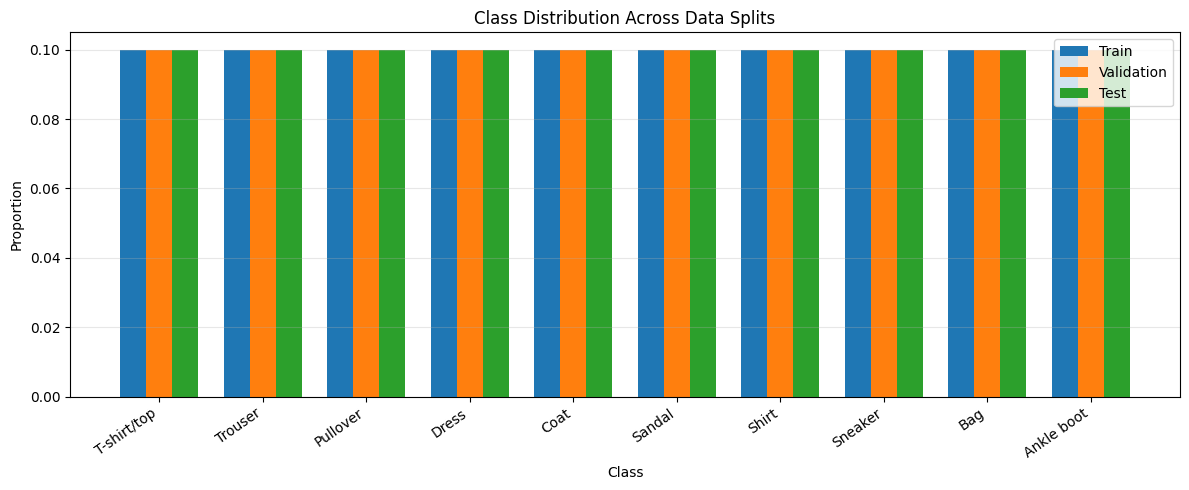

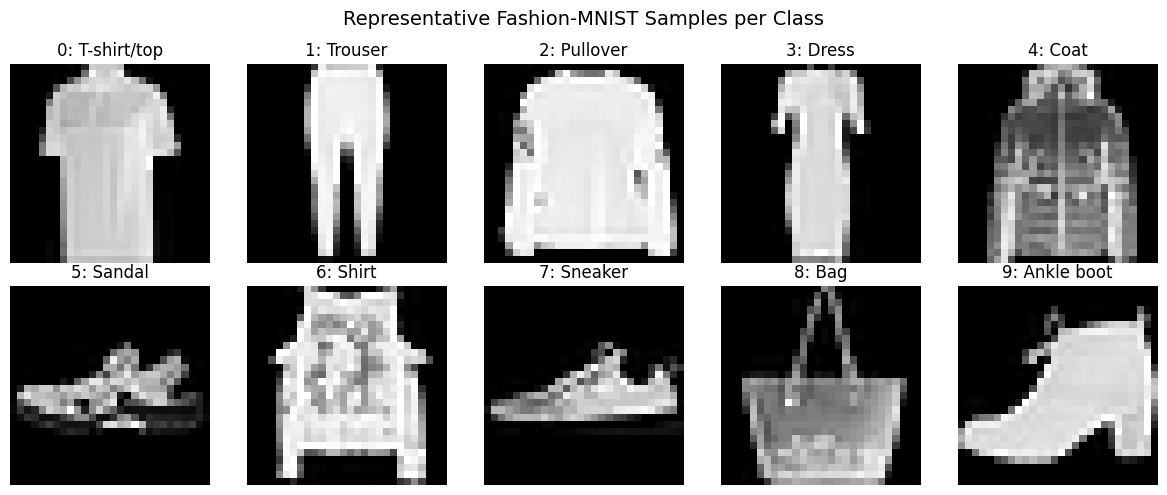

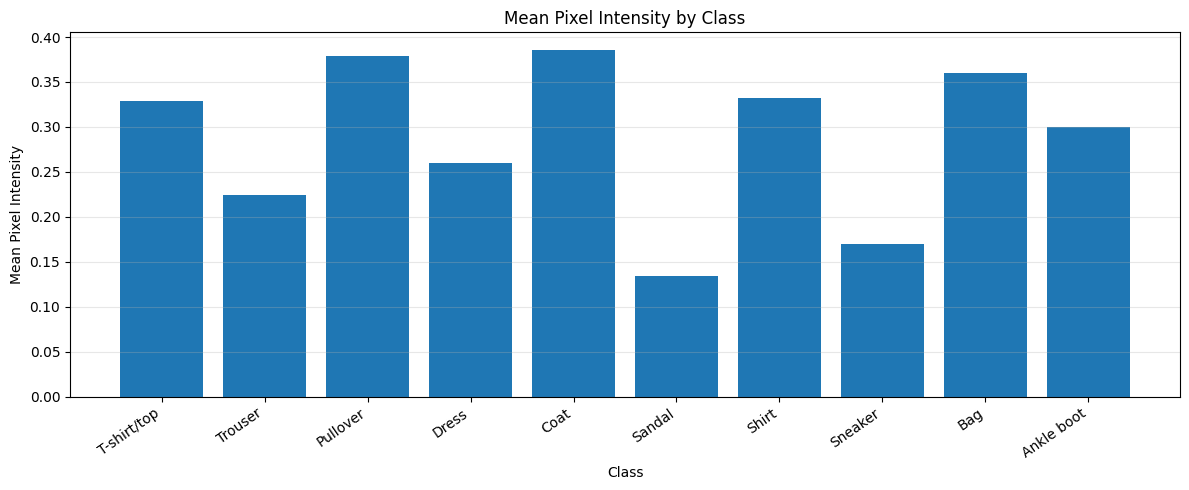


Exploratory Data Analysis Summary
Class distribution CSV saved to : dcgan_fmnist_research_deployment/outputs/eda_class_distribution.csv
Imbalance summary saved to      : dcgan_fmnist_research_deployment/outputs/eda_imbalance_summary.csv
JS distance summary saved to    : dcgan_fmnist_research_deployment/outputs/eda_jensen_shannon_distance.csv
Pixel statistics saved to       : dcgan_fmnist_research_deployment/outputs/eda_pixel_intensity_by_class.csv
Figure saved to                 : dcgan_fmnist_research_deployment/figures/eda_class_distribution.png
Figure saved to                 : dcgan_fmnist_research_deployment/figures/eda_representative_samples.png
Figure saved to                 : dcgan_fmnist_research_deployment/figures/eda_mean_pixel_intensity_by_class.png


,split,class_id,class_name,count,proportion
0,train,0,T-shirt/top,540,0.1
1,train,1,Trouser,540,0.1
2,train,2,Pullover,540,0.1
3,train,3,Dress,540,0.1
4,train,4,Coat,540,0.1
5,train,5,Sandal,540,0.1
6,train,6,Shirt,540,0.1
7,train,7,Sneaker,540,0.1
8,train,8,Bag,540,0.1
9,train,9,Ankle boot,540,0.1


,split,imbalance_ratio,status
0,train,1.0,Class distribution acceptable
1,validation,1.0,Class distribution acceptable
2,test,1.0,Class distribution acceptable


,comparison,jensen_shannon_distance
0,train_vs_validation,0.0
1,train_vs_test,0.0
2,validation_vs_test,0.0


,class_id,class_name,mean_pixel_intensity,std_pixel_intensity,sample_count
0,0,T-shirt/top,0.328783,0.113997,540
1,1,Trouser,0.224539,0.054510,540
2,2,Pullover,0.379122,0.124729,540
3,3,Dress,0.260311,0.082738,540
4,4,Coat,0.385912,0.099980,540
5,5,Sandal,0.134367,0.058780,540
6,6,Shirt,0.331589,0.129334,540
7,7,Sneaker,0.170127,0.050832,540
8,8,Bag,0.359465,0.113042,540
9,9,Ankle boot,0.299643,0.071988,540


,diagnostic_aspect,value_or_interpretation
0,Maximum imbalance ratio,1.0
1,Maximum Jensen-Shannon distance,0.0
2,Imbalance interpretation,The stratified 10% subset preserves class bala...
3,Distribution shift interpretation,"The class distributions across train, validati..."


In [7]:
# ============================================================
# Step 4 — Exploratory Data Analysis and Bias Diagnostics
# ============================================================
# Deskripsi:
# Cell ini melakukan eksplorasi data awal untuk memeriksa distribusi kelas,
# potensi imbalance, jarak distribusi antar-split, statistik intensitas piksel,
# dan visualisasi sampel citra asli.
#
# Prinsip integritas:
# 1. EDA dilakukan sebelum training agar bias data dapat diketahui sejak awal.
# 2. Semua grafik dan tabel disimpan ke folder proyek.
# 3. Diagnosis imbalance bersifat berbasis data, bukan asumsi.
# 4. Hasil EDA tidak digunakan untuk mengklaim performa model.

# ------------------------------------------------------------
# Fungsi mengambil label dari Subset.
# Fungsi ini aman karena Subset menyimpan indeks dari dataset induk.
# ------------------------------------------------------------

def labels_from_subset_targets(full_targets: np.ndarray, subset_indices: np.ndarray) -> np.ndarray:
    """Mengambil label berdasarkan indeks subset dari target dataset penuh."""
    return full_targets[subset_indices]

train_labels = labels_from_subset_targets(train_targets_full, train_idx)
val_labels = labels_from_subset_targets(train_targets_full, val_idx)
test_labels = labels_from_subset_targets(test_targets_full, test_idx)

# ------------------------------------------------------------
# Fungsi membuat ringkasan statistik distribusi kelas.
# ------------------------------------------------------------

def summarize_class_distribution(labels: np.ndarray, split_name: str) -> pd.DataFrame:
    """Meringkas jumlah dan proporsi kelas untuk satu split data."""
    counts = np.bincount(labels, minlength=10)
    proportions = counts / counts.sum()

    return pd.DataFrame({
        "split": split_name,
        "class_id": np.arange(10),
        "class_name": CLASS_NAMES,
        "count": counts,
        "proportion": proportions
    })

eda_train_df = summarize_class_distribution(train_labels, "train")
eda_val_df = summarize_class_distribution(val_labels, "validation")
eda_test_df = summarize_class_distribution(test_labels, "test")

eda_distribution_df = pd.concat(
    [eda_train_df, eda_val_df, eda_test_df],
    ignore_index=True
)

eda_distribution_path = OUTPUT_DIR / "eda_class_distribution.csv"
eda_distribution_df.to_csv(eda_distribution_path, index=False)

# ------------------------------------------------------------
# Imbalance ratio.
# Rasio dihitung dari kelas terbanyak dibagi kelas tersedikit.
# Semakin dekat ke 1.0, distribusi semakin seimbang.
# ------------------------------------------------------------

def imbalance_ratio(labels: np.ndarray) -> float:
    """Menghitung rasio imbalance berdasarkan jumlah kelas maksimum/minimum."""
    counts = np.bincount(labels, minlength=10)
    min_count = counts[counts > 0].min()
    max_count = counts.max()
    return float(max_count / min_count)

imbalance_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "imbalance_ratio": [
        imbalance_ratio(train_labels),
        imbalance_ratio(val_labels),
        imbalance_ratio(test_labels)
    ]
})

imbalance_summary["status"] = np.where(
    imbalance_summary["imbalance_ratio"] > CONFIG["imbalance_threshold"],
    "Potential imbalance detected",
    "Class distribution acceptable"
)

imbalance_path = OUTPUT_DIR / "eda_imbalance_summary.csv"
imbalance_summary.to_csv(imbalance_path, index=False)

# ------------------------------------------------------------
# Jensen-Shannon distance antar distribusi kelas.
# Nilai kecil menunjukkan distribusi antar-split relatif mirip.
# Catatan:
# scipy.spatial.distance.jensenshannon mengembalikan distance,
# bukan divergence mentah.
# ------------------------------------------------------------

train_prob = np.bincount(train_labels, minlength=10) / len(train_labels)
val_prob = np.bincount(val_labels, minlength=10) / len(val_labels)
test_prob = np.bincount(test_labels, minlength=10) / len(test_labels)

js_summary = pd.DataFrame({
    "comparison": ["train_vs_validation", "train_vs_test", "validation_vs_test"],
    "jensen_shannon_distance": [
        float(jensenshannon(train_prob, val_prob)),
        float(jensenshannon(train_prob, test_prob)),
        float(jensenshannon(val_prob, test_prob))
    ]
})

js_path = OUTPUT_DIR / "eda_jensen_shannon_distance.csv"
js_summary.to_csv(js_path, index=False)

# ------------------------------------------------------------
# Visualisasi distribusi kelas.
# Judul grafik menggunakan Bahasa Inggris sesuai standar output program.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(CLASS_NAMES))
width = 0.25

ax.bar(x - width, train_prob, width, label="Train")
ax.bar(x, val_prob, width, label="Validation")
ax.bar(x + width, test_prob, width, label="Test")

ax.set_title("Class Distribution Across Data Splits")
ax.set_xlabel("Class")
ax.set_ylabel("Proportion")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

class_dist_fig_path = FIGURE_DIR / "eda_class_distribution.png"
plt.tight_layout()
plt.savefig(class_dist_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Fungsi denormalisasi sederhana untuk visualisasi.
# Untuk data raw EDA, tensor sudah berada dalam rentang [0, 1],
# sehingga tidak perlu denormalisasi khusus.
# ------------------------------------------------------------

def tensor_to_numpy_image(tensor_img: torch.Tensor) -> np.ndarray:
    """Mengubah tensor citra [1, H, W] menjadi array [H, W] untuk plot grayscale."""
    if tensor_img.ndim == 3:
        tensor_img = tensor_img.squeeze(0)
    return tensor_img.detach().cpu().numpy()

# ------------------------------------------------------------
# Visualisasi satu sampel per kelas dari train_raw_subset.
# ------------------------------------------------------------

def get_one_sample_per_class(dataset_subset, subset_indices: np.ndarray, full_targets: np.ndarray):
    """Mengambil satu sampel citra untuk setiap kelas dari subset."""
    selected = {}
    for local_pos, original_idx in enumerate(subset_indices):
        label = int(full_targets[original_idx])
        if label not in selected:
            img, _ = dataset_subset[local_pos]
            selected[label] = img
        if len(selected) == 10:
            break
    return selected

samples_per_class = get_one_sample_per_class(
    train_raw_subset,
    train_idx,
    train_targets_full
)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for class_id in range(10):
    axes[class_id].imshow(
        tensor_to_numpy_image(samples_per_class[class_id]),
        cmap="gray"
    )
    axes[class_id].set_title(f"{class_id}: {CLASS_NAMES[class_id]}")
    axes[class_id].axis("off")

fig.suptitle("Representative Fashion-MNIST Samples per Class", fontsize=14)
sample_fig_path = FIGURE_DIR / "eda_representative_samples.png"
plt.tight_layout()
plt.savefig(sample_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Statistik intensitas piksel per kelas.
# Statistik ini membantu melihat apakah ada kelas dengan karakteristik
# intensitas yang sangat berbeda dan berpotensi memengaruhi model.
# ------------------------------------------------------------

def compute_pixel_intensity_by_class(dataset_subset, subset_indices: np.ndarray, full_targets: np.ndarray) -> pd.DataFrame:
    """Menghitung rata-rata dan deviasi standar intensitas piksel per kelas."""
    records = []

    for class_id in range(10):
        pixel_means = []

        for local_pos, original_idx in enumerate(subset_indices):
            if int(full_targets[original_idx]) == class_id:
                img, _ = dataset_subset[local_pos]
                pixel_means.append(float(img.mean().item()))

        records.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "mean_pixel_intensity": float(np.mean(pixel_means)),
            "std_pixel_intensity": float(np.std(pixel_means)),
            "sample_count": len(pixel_means)
        })

    return pd.DataFrame(records)

pixel_stats_df = compute_pixel_intensity_by_class(
    train_raw_subset,
    train_idx,
    train_targets_full
)

pixel_stats_path = OUTPUT_DIR / "eda_pixel_intensity_by_class.csv"
pixel_stats_df.to_csv(pixel_stats_path, index=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(pixel_stats_df["class_name"], pixel_stats_df["mean_pixel_intensity"])
ax.set_title("Mean Pixel Intensity by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Mean Pixel Intensity")
ax.set_xticklabels(pixel_stats_df["class_name"], rotation=35, ha="right")
ax.grid(axis="y", alpha=0.3)

pixel_fig_path = FIGURE_DIR / "eda_mean_pixel_intensity_by_class.png"
plt.tight_layout()
plt.savefig(pixel_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Insight otomatis berbasis EDA.
# Insight ini tidak mengklaim performa model, tetapi memberi diagnosis awal.
# ------------------------------------------------------------

max_imbalance = float(imbalance_summary["imbalance_ratio"].max())
max_js_distance = float(js_summary["jensen_shannon_distance"].max())

if max_imbalance <= CONFIG["imbalance_threshold"]:
    imbalance_insight = (
        "The stratified 10% subset preserves class balance under the configured threshold."
    )
else:
    imbalance_insight = (
        "Potential imbalance is detected; imbalance prevention will be activated in DataLoader construction."
    )

if max_js_distance < 0.05:
    js_insight = (
        "The class distributions across train, validation, and test splits are highly similar."
    )
elif max_js_distance < 0.10:
    js_insight = (
        "The class distributions show minor distributional shift and should be monitored."
    )
else:
    js_insight = (
        "The class distributions show noticeable shift; evaluation must be interpreted cautiously."
    )

eda_insight_df = pd.DataFrame({
    "diagnostic_aspect": [
        "Maximum imbalance ratio",
        "Maximum Jensen-Shannon distance",
        "Imbalance interpretation",
        "Distribution shift interpretation"
    ],
    "value_or_interpretation": [
        round(max_imbalance, 4),
        round(max_js_distance, 4),
        imbalance_insight,
        js_insight
    ]
})

eda_insight_path = OUTPUT_DIR / "eda_diagnostic_insights.csv"
eda_insight_df.to_csv(eda_insight_path, index=False)

print("\nExploratory Data Analysis Summary")
print("=" * 70)
print(f"Class distribution CSV saved to : {eda_distribution_path}")
print(f"Imbalance summary saved to      : {imbalance_path}")
print(f"JS distance summary saved to    : {js_path}")
print(f"Pixel statistics saved to       : {pixel_stats_path}")
print(f"Figure saved to                 : {class_dist_fig_path}")
print(f"Figure saved to                 : {sample_fig_path}")
print(f"Figure saved to                 : {pixel_fig_path}")
print("=" * 70)

display(eda_distribution_df)
display(imbalance_summary)
display(js_summary)
display(pixel_stats_df)
display(eda_insight_df)

In [8]:
# ============================================================
# Step 5 — DataLoader Construction with Imbalance Prevention
# ============================================================
# Deskripsi:
# Cell ini membangun DataLoader untuk classifier evaluator, DCGAN,
# validation, dan test. Jika EDA menunjukkan imbalance melebihi ambang,
# program akan mengaktifkan WeightedRandomSampler. Jika distribusi masih
# seimbang, program memakai seeded shuffle agar tetap reproducible.
#
# Prinsip integritas:
# 1. Pencegahan imbalance hanya diaktifkan bila ada bukti dari EDA.
# 2. DataLoader training dan evaluasi dibedakan agar tidak terjadi data leakage.
# 3. Validation dan test tidak memakai augmentasi.
# 4. Sampler dan shuffle tidak digunakan bersamaan karena dapat menimbulkan
#    konflik logika sampling.

# ------------------------------------------------------------
# Fungsi worker_init_fn untuk menjaga reproducibility DataLoader.
# Setiap worker diberi seed turunan agar operasi acak lebih terkendali.
# ------------------------------------------------------------

def seed_worker(worker_id: int) -> None:
    """Mengatur seed pada setiap worker DataLoader."""
    worker_seed = CONFIG["seed"] + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# ------------------------------------------------------------
# Fungsi membuat bobot sampel untuk WeightedRandomSampler.
# Bobot dihitung berdasarkan frekuensi kelas pada train split.
# Kelas dengan jumlah data lebih kecil akan memperoleh bobot lebih besar.
# ------------------------------------------------------------

def compute_sample_weights(labels: np.ndarray) -> torch.DoubleTensor:
    """
    Menghitung bobot per sampel berdasarkan inverse class frequency.
    Pendekatan ini relevan ketika distribusi kelas tidak seimbang.
    """
    class_counts = np.bincount(labels, minlength=10).astype(np.float64)

    if np.any(class_counts == 0):
        raise ValueError(
            "Terdapat kelas dengan jumlah 0 pada train split. "
            "Periksa kembali stratified sampling."
        )

    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]

    return torch.DoubleTensor(sample_weights)

# ------------------------------------------------------------
# Diagnosis final apakah imbalance prevention perlu diaktifkan.
# Keputusan berbasis nilai imbalance ratio dari EDA, bukan asumsi.
# ------------------------------------------------------------

train_imbalance_ratio = float(
    imbalance_summary.loc[
        imbalance_summary["split"] == "train",
        "imbalance_ratio"
    ].iloc[0]
)

USE_WEIGHTED_SAMPLER = train_imbalance_ratio > CONFIG["imbalance_threshold"]

if USE_WEIGHTED_SAMPLER:
    train_sample_weights = compute_sample_weights(train_labels)

    train_sampler = WeightedRandomSampler(
        weights=train_sample_weights,
        num_samples=len(train_sample_weights),
        replacement=True,
        generator=DATALOADER_GENERATOR
    )

    shuffle_train = False
    sampler_status = "WeightedRandomSampler activated"
else:
    train_sampler = None
    shuffle_train = True
    sampler_status = "Seeded shuffle activated"

# ------------------------------------------------------------
# DataLoader untuk classifier evaluator.
# Classifier menggunakan dataset augmentasi pada train set.
# Validation dan test menggunakan data normal tanpa augmentasi.
# ------------------------------------------------------------

classifier_train_loader = DataLoader(
    train_aug_subset,
    batch_size=CONFIG["batch_size"],
    shuffle=shuffle_train,
    sampler=train_sampler,
    num_workers=CONFIG["num_workers"],
    worker_init_fn=seed_worker,
    generator=DATALOADER_GENERATOR,
    pin_memory=torch.cuda.is_available()
)

classifier_val_loader = DataLoader(
    val_norm_subset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    worker_init_fn=seed_worker,
    generator=DATALOADER_GENERATOR,
    pin_memory=torch.cuda.is_available()
)

classifier_test_loader = DataLoader(
    test_norm_subset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    worker_init_fn=seed_worker,
    generator=DATALOADER_GENERATOR,
    pin_memory=torch.cuda.is_available()
)

# ------------------------------------------------------------
# DataLoader untuk DCGAN.
# DCGAN tidak membutuhkan label kelas dalam proses training.
# Dataset normal dipakai karena citra harus berada pada rentang [-1, 1].
# ------------------------------------------------------------

dcgan_train_loader = DataLoader(
    train_norm_subset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    worker_init_fn=seed_worker,
    generator=DATALOADER_GENERATOR,
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)

# ------------------------------------------------------------
# DataLoader untuk EDA lanjutan dan visualisasi test.
# ------------------------------------------------------------

test_raw_loader = DataLoader(
    test_raw_subset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    worker_init_fn=seed_worker,
    generator=DATALOADER_GENERATOR
)

# ------------------------------------------------------------
# Sanity check shape batch.
# Ini penting agar error dimensi dapat diketahui sebelum training model.
# ------------------------------------------------------------

classifier_batch_images, classifier_batch_labels = next(iter(classifier_train_loader))
dcgan_batch_images, dcgan_batch_labels = next(iter(dcgan_train_loader))

assert classifier_batch_images.ndim == 4, "Batch classifier harus berbentuk [B, C, H, W]."
assert dcgan_batch_images.ndim == 4, "Batch DCGAN harus berbentuk [B, C, H, W]."

assert classifier_batch_images.shape[1:] == torch.Size([1, 28, 28]), (
    "Shape citra classifier tidak sesuai. Harus [1, 28, 28]."
)

assert dcgan_batch_images.shape[1:] == torch.Size([1, 28, 28]), (
    "Shape citra DCGAN tidak sesuai. Harus [1, 28, 28]."
)

assert classifier_batch_labels.min() >= 0 and classifier_batch_labels.max() <= 9, (
    "Label classifier harus berada pada rentang 0–9."
)

# ------------------------------------------------------------
# Simpan ringkasan DataLoader agar keputusan sampling terdokumentasi.
# ------------------------------------------------------------

dataloader_summary = {
    "sampler_status": sampler_status,
    "use_weighted_sampler": bool(USE_WEIGHTED_SAMPLER),
    "train_imbalance_ratio": train_imbalance_ratio,
    "batch_size": CONFIG["batch_size"],
    "num_workers": CONFIG["num_workers"],
    "classifier_train_batches": len(classifier_train_loader),
    "classifier_validation_batches": len(classifier_val_loader),
    "classifier_test_batches": len(classifier_test_loader),
    "dcgan_train_batches": len(dcgan_train_loader),
    "classifier_batch_shape": list(classifier_batch_images.shape),
    "dcgan_batch_shape": list(dcgan_batch_images.shape)
}

dataloader_summary_path = OUTPUT_DIR / "dataloader_construction_summary.json"

with open(dataloader_summary_path, "w", encoding="utf-8") as f:
    json.dump(dataloader_summary, f, indent=4, ensure_ascii=False)

dataloader_summary_df = pd.DataFrame([
    {
        "item": key,
        "value": value
    }
    for key, value in dataloader_summary.items()
])

dataloader_summary_csv_path = OUTPUT_DIR / "dataloader_construction_summary.csv"
dataloader_summary_df.to_csv(dataloader_summary_csv_path, index=False)

print("\nDataLoader Construction Summary")
print("=" * 70)
print(f"Sampler status          : {sampler_status}")
print(f"Weighted sampler used   : {USE_WEIGHTED_SAMPLER}")
print(f"Train imbalance ratio   : {train_imbalance_ratio:.4f}")
print(f"Classifier batch shape  : {list(classifier_batch_images.shape)}")
print(f"DCGAN batch shape       : {list(dcgan_batch_images.shape)}")
print(f"Summary JSON saved to   : {dataloader_summary_path}")
print(f"Summary CSV saved to    : {dataloader_summary_csv_path}")
print("=" * 70)

display(dataloader_summary_df)


DataLoader Construction Summary
Sampler status          : Seeded shuffle activated
Weighted sampler used   : False
Train imbalance ratio   : 1.0000
Classifier batch shape  : [128, 1, 28, 28]
DCGAN batch shape       : [128, 1, 28, 28]
Summary JSON saved to   : dcgan_fmnist_research_deployment/outputs/dataloader_construction_summary.json
Summary CSV saved to    : dcgan_fmnist_research_deployment/outputs/dataloader_construction_summary.csv


,item,value
0,sampler_status,Seeded shuffle activated
1,use_weighted_sampler,False
2,train_imbalance_ratio,1.0
3,batch_size,128
4,num_workers,2
5,classifier_train_batches,43
6,classifier_validation_batches,5
7,classifier_test_batches,8
8,dcgan_train_batches,42
9,classifier_batch_shape,"[128, 1, 28, 28]"


Epoch 001 | Train Loss: 1.5369 | Train Acc: 0.5113 | Val Loss: 1.1398 | Val Acc: 0.6767
Epoch 002 | Train Loss: 1.0588 | Train Acc: 0.6776 | Val Loss: 0.8242 | Val Acc: 0.7633
Epoch 003 | Train Loss: 0.8631 | Train Acc: 0.7181 | Val Loss: 0.7742 | Val Acc: 0.7383


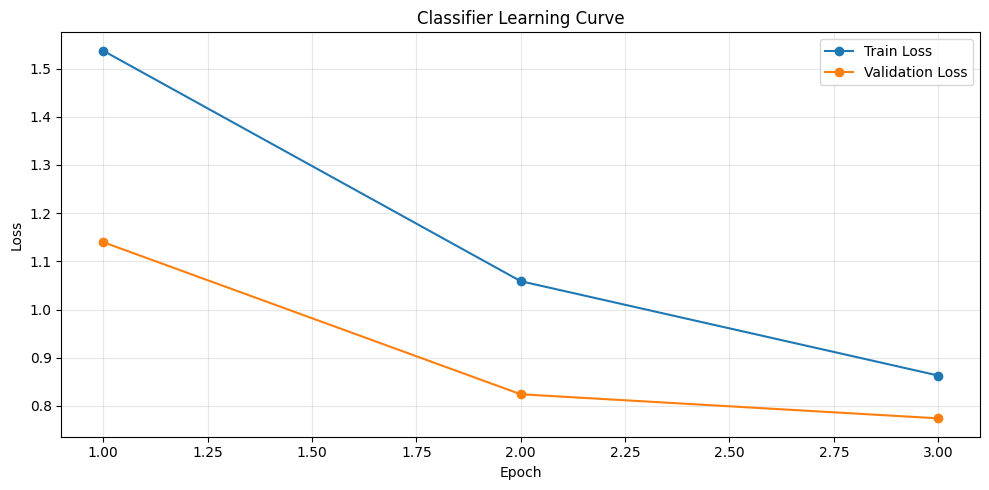

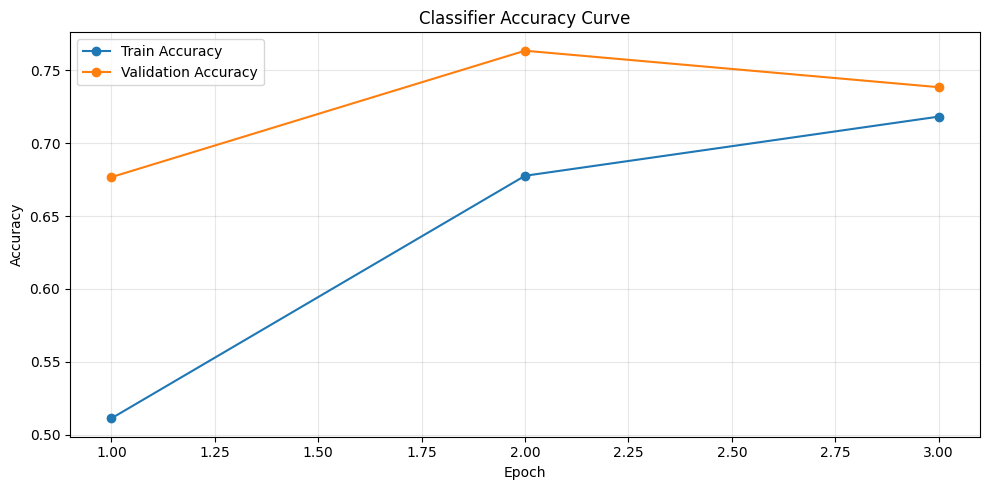

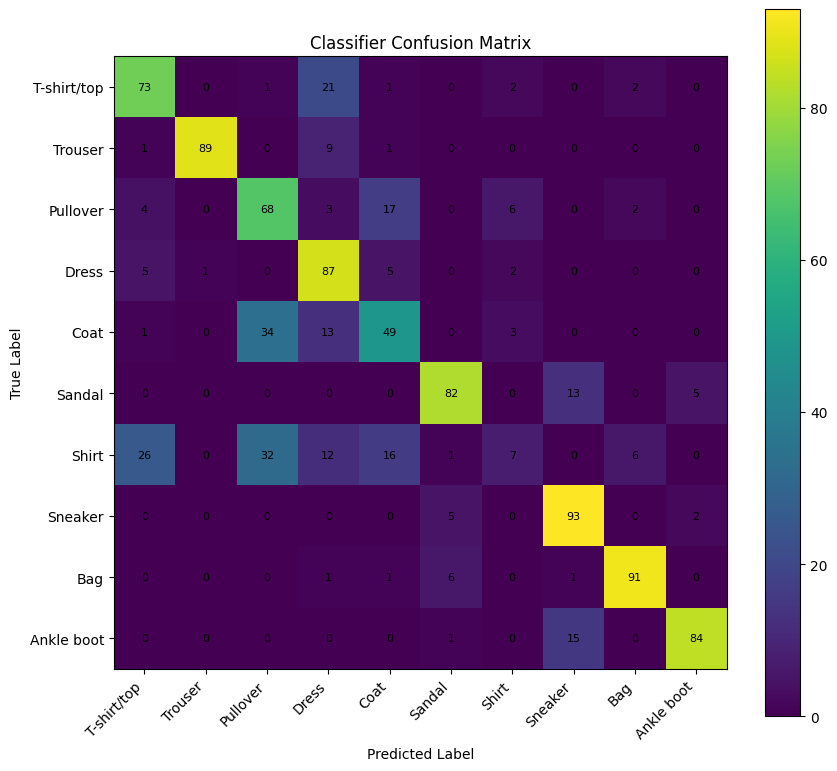


Classifier Evaluation Report
Best validation accuracy     : 0.7633
Test accuracy                : 0.7230
Fit status                   : Acceptable generalization pattern
Training history saved to    : dcgan_fmnist_research_deployment/outputs/classifier_training_history.csv
Classification report saved  : dcgan_fmnist_research_deployment/outputs/classifier_evaluation_report.csv
Confusion matrix saved to    : dcgan_fmnist_research_deployment/outputs/classifier_confusion_matrix.csv
Model state_dict saved to    : dcgan_fmnist_research_deployment/models/fashion_mnist_classifier_state_dict.pt
Joblib artifact saved to     : dcgan_fmnist_research_deployment/models/fashion_mnist_classifier_artifact.joblib


,precision,recall,f1-score,support
T-shirt/top,0.663636,0.730,0.695238,100.000
Trouser,0.988889,0.890,0.936842,100.000
Pullover,0.503704,0.680,0.578723,100.000
Dress,0.595890,0.870,0.707317,100.000
Coat,0.544444,0.490,0.515789,100.000
Sandal,0.863158,0.820,0.841026,100.000
Shirt,0.350000,0.070,0.116667,100.000
Sneaker,0.762295,0.930,0.837838,100.000
Bag,0.900990,0.910,0.905473,100.000
Ankle boot,0.923077,0.840,0.879581,100.000


,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
T-shirt/top,73,0,1,21,1,0,2,0,2,0
Trouser,1,89,0,9,1,0,0,0,0,0
Pullover,4,0,68,3,17,0,6,0,2,0
Dress,5,1,0,87,5,0,2,0,0,0
Coat,1,0,34,13,49,0,3,0,0,0
Sandal,0,0,0,0,0,82,0,13,0,5
Shirt,26,0,32,12,16,1,7,0,6,0
Sneaker,0,0,0,0,0,5,0,93,0,2
Bag,0,0,0,1,1,6,0,1,91,0
Ankle boot,0,0,0,0,0,1,0,15,0,84


,diagnostic_aspect,value_or_interpretation
0,Final train accuracy,0.7181
1,Final validation accuracy,0.7383
2,Generalization gap,-0.0202
3,Test accuracy,0.723
4,Fit status,Acceptable generalization pattern
5,Interpretation,The train-validation gap is within the configu...


In [9]:
# ============================================================
# Step 6 — Classifier Evaluator Training and Evaluation
# ============================================================
# Deskripsi:
# Cell ini membangun dan melatih classifier evaluator berbasis CNN.
# Classifier ini digunakan untuk dua tujuan:
# 1. Mengevaluasi klasifikasi Fashion-MNIST pada data asli.
# 2. Menjadi feature extractor dan alat bantu analisis distribusi kelas
#    untuk gambar sintetis DCGAN pada tahap berikutnya.
#
# Prinsip integritas:
# 1. Classifier hanya dilatih pada data asli, bukan pada data sintetis.
# 2. Validation set digunakan untuk memantau underfitting/overfitting.
# 3. Test set hanya digunakan untuk evaluasi akhir classifier.
# 4. Nilai metrik tidak ditulis manual, tetapi dihitung dari runtime.

# ------------------------------------------------------------
# Definisi model classifier evaluator.
# Output terakhir berupa logit mentah untuk 10 kelas.
# Jangan menambahkan Softmax pada forward karena CrossEntropyLoss
# sudah menangani logit secara numerik lebih stabil.
# ------------------------------------------------------------

class FashionMNISTClassifier(nn.Module):
    """CNN sederhana untuk evaluasi Fashion-MNIST dan ekstraksi fitur."""

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # [B, 32, 28, 28]
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # [B, 32, 14, 14]

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # [B, 64, 14, 14]
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # [B, 64, 7, 7]

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # [B, 128, 7, 7]
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))                 # [B, 128, 1, 1]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        """Mengambil embedding fitur untuk evaluasi generatif."""
        features = self.feature_extractor(x)
        return torch.flatten(features, start_dim=1)


classifier_model = FashionMNISTClassifier(num_classes=10).to(DEVICE)

# ------------------------------------------------------------
# Sanity check dimensi model.
# Tujuannya memastikan bahwa classifier menerima input [B, 1, 28, 28]
# dan menghasilkan logit [B, 10].
# ------------------------------------------------------------

with torch.no_grad():
    dummy_input = torch.randn(4, 1, 28, 28).to(DEVICE)
    dummy_logits = classifier_model(dummy_input)
    dummy_features = classifier_model.extract_features(dummy_input)

assert dummy_logits.shape == torch.Size([4, 10]), "Output classifier harus [B, 10]."
assert dummy_features.ndim == 2 and dummy_features.shape[0] == 4, (
    "Feature extractor harus menghasilkan tensor [B, feature_dim]."
)

# ------------------------------------------------------------
# Loss dan optimizer.
# Weight decay dipakai sebagai regularisasi ringan untuk mengurangi risiko overfitting.
# ------------------------------------------------------------

classifier_criterion = nn.CrossEntropyLoss()
classifier_optimizer = optim.Adam(
    classifier_model.parameters(),
    lr=CONFIG["classifier_lr"],
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Fungsi training satu epoch.
# ------------------------------------------------------------

def train_classifier_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion,
    optimizer,
    device: torch.device
) -> dict:
    """Melatih classifier untuk satu epoch dan mengembalikan metrik ringkas."""
    model.train()

    total_loss = 0.0
    all_true = []
    all_pred = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * images.size(0)

        preds = torch.argmax(logits, dim=1)
        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(data_loader.dataset)
    epoch_acc = accuracy_score(all_true, all_pred)

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc
    }

# ------------------------------------------------------------
# Fungsi evaluasi classifier.
# ------------------------------------------------------------

def evaluate_classifier(
    model: nn.Module,
    data_loader: DataLoader,
    criterion,
    device: torch.device
) -> dict:
    """Mengevaluasi classifier tanpa memperbarui bobot model."""
    model.eval()

    total_loss = 0.0
    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += float(loss.item()) * images.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_true.extend(labels.detach().cpu().numpy().tolist())
            all_pred.extend(preds.detach().cpu().numpy().tolist())
            all_prob.extend(probs.detach().cpu().numpy().tolist())

    epoch_loss = total_loss / len(data_loader.dataset)
    epoch_acc = accuracy_score(all_true, all_pred)

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "y_true": np.asarray(all_true),
        "y_pred": np.asarray(all_pred),
        "y_prob": np.asarray(all_prob)
    }

# ------------------------------------------------------------
# Training loop classifier.
# Early stopping sederhana dipakai agar training tidak berlebihan
# pada subset 10%. Model terbaik dipilih berdasarkan validation accuracy.
# ------------------------------------------------------------

classifier_history = []
best_val_accuracy = -np.inf
best_classifier_state = None
patience = 3
patience_counter = 0

for epoch in range(1, CONFIG["classifier_epochs"] + 1):
    train_metrics = train_classifier_one_epoch(
        model=classifier_model,
        data_loader=classifier_train_loader,
        criterion=classifier_criterion,
        optimizer=classifier_optimizer,
        device=DEVICE
    )

    val_metrics = evaluate_classifier(
        model=classifier_model,
        data_loader=classifier_val_loader,
        criterion=classifier_criterion,
        device=DEVICE
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "validation_loss": val_metrics["loss"],
        "validation_accuracy": val_metrics["accuracy"]
    }

    classifier_history.append(epoch_record)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f}"
    )

    if val_metrics["accuracy"] > best_val_accuracy:
        best_val_accuracy = val_metrics["accuracy"]
        best_classifier_state = {
            key: value.detach().cpu().clone()
            for key, value in classifier_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping activated based on validation accuracy.")
        break

# ------------------------------------------------------------
# Muat kembali bobot classifier terbaik.
# ------------------------------------------------------------

if best_classifier_state is not None:
    classifier_model.load_state_dict(best_classifier_state)

# ------------------------------------------------------------
# Evaluasi akhir pada test subset.
# Test set tidak digunakan untuk memilih model.
# ------------------------------------------------------------

test_metrics = evaluate_classifier(
    model=classifier_model,
    data_loader=classifier_test_loader,
    criterion=classifier_criterion,
    device=DEVICE
)

classifier_history_df = pd.DataFrame(classifier_history)
classifier_history_path = OUTPUT_DIR / "classifier_training_history.csv"
classifier_history_df.to_csv(classifier_history_path, index=False)

# ------------------------------------------------------------
# Classification report dan confusion matrix.
# ------------------------------------------------------------

classifier_report_dict = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

classifier_report_df = pd.DataFrame(classifier_report_dict).transpose()
classifier_report_path = OUTPUT_DIR / "classifier_evaluation_report.csv"
classifier_report_df.to_csv(classifier_report_path, index=True)

classifier_confusion_matrix = confusion_matrix(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=np.arange(10)
)

confusion_matrix_df = pd.DataFrame(
    classifier_confusion_matrix,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

confusion_matrix_path = OUTPUT_DIR / "classifier_confusion_matrix.csv"
confusion_matrix_df.to_csv(confusion_matrix_path, index=True)

# ------------------------------------------------------------
# Visualisasi learning curve.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(classifier_history_df["epoch"], classifier_history_df["train_loss"], marker="o", label="Train Loss")
ax.plot(classifier_history_df["epoch"], classifier_history_df["validation_loss"], marker="o", label="Validation Loss")
ax.set_title("Classifier Learning Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3)
ax.legend()

classifier_loss_fig_path = FIGURE_DIR / "classifier_learning_curve.png"
plt.tight_layout()
plt.savefig(classifier_loss_fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(classifier_history_df["epoch"], classifier_history_df["train_accuracy"], marker="o", label="Train Accuracy")
ax.plot(classifier_history_df["epoch"], classifier_history_df["validation_accuracy"], marker="o", label="Validation Accuracy")
ax.set_title("Classifier Accuracy Curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.grid(alpha=0.3)
ax.legend()

classifier_accuracy_fig_path = FIGURE_DIR / "classifier_accuracy_curve.png"
plt.tight_layout()
plt.savefig(classifier_accuracy_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Visualisasi confusion matrix.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(classifier_confusion_matrix)

ax.set_title("Classifier Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)

for i in range(10):
    for j in range(10):
        ax.text(
            j, i,
            str(classifier_confusion_matrix[i, j]),
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(im, ax=ax)
classifier_cm_fig_path = FIGURE_DIR / "classifier_confusion_matrix.png"
plt.tight_layout()
plt.savefig(classifier_cm_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Diagnosis underfitting dan overfitting.
# Diagnosis ini bersifat heuristik, bukan klaim mutlak.
# ------------------------------------------------------------

final_train_acc = float(classifier_history_df["train_accuracy"].iloc[-1])
final_val_acc = float(classifier_history_df["validation_accuracy"].iloc[-1])
generalization_gap = final_train_acc - final_val_acc

if final_train_acc < 0.70 and final_val_acc < 0.70:
    fit_status = "Potential underfitting"
    fit_insight = (
        "Train and validation accuracy are both low. "
        "The classifier may require more epochs, better architecture, or less restrictive augmentation."
    )
elif generalization_gap > 0.10:
    fit_status = "Potential overfitting"
    fit_insight = (
        "Train accuracy is substantially higher than validation accuracy. "
        "Regularization, data augmentation, or early stopping should be strengthened."
    )
else:
    fit_status = "Acceptable generalization pattern"
    fit_insight = (
        "The train-validation gap is within the configured heuristic boundary. "
        "The classifier is acceptable as an auxiliary evaluator."
    )

classifier_diagnostic_df = pd.DataFrame({
    "diagnostic_aspect": [
        "Final train accuracy",
        "Final validation accuracy",
        "Generalization gap",
        "Test accuracy",
        "Fit status",
        "Interpretation"
    ],
    "value_or_interpretation": [
        round(final_train_acc, 4),
        round(final_val_acc, 4),
        round(generalization_gap, 4),
        round(float(test_metrics["accuracy"]), 4),
        fit_status,
        fit_insight
    ]
})

classifier_diagnostic_path = OUTPUT_DIR / "classifier_fit_diagnostics.csv"
classifier_diagnostic_df.to_csv(classifier_diagnostic_path, index=False)

# ------------------------------------------------------------
# Simpan model classifier.
# .pt menyimpan state_dict PyTorch.
# .joblib menyimpan paket artefak untuk deployment internal.
# Catatan keamanan: file joblib/pickle hanya boleh dimuat dari sumber tepercaya.
# ------------------------------------------------------------

classifier_pt_path = MODEL_DIR / "fashion_mnist_classifier_state_dict.pt"
torch.save(
    {
        "model_state_dict": classifier_model.state_dict(),
        "class_names": CLASS_NAMES,
        "config": CONFIG,
        "test_accuracy": float(test_metrics["accuracy"])
    },
    classifier_pt_path
)

classifier_joblib_path = MODEL_DIR / "fashion_mnist_classifier_artifact.joblib"
joblib.dump(
    {
        "model_class": "FashionMNISTClassifier",
        "model_state_dict": classifier_model.state_dict(),
        "class_names": CLASS_NAMES,
        "config": CONFIG,
        "test_accuracy": float(test_metrics["accuracy"])
    },
    classifier_joblib_path
)

print("\nClassifier Evaluation Report")
print("=" * 70)
print(f"Best validation accuracy     : {best_val_accuracy:.4f}")
print(f"Test accuracy                : {float(test_metrics['accuracy']):.4f}")
print(f"Fit status                   : {fit_status}")
print(f"Training history saved to    : {classifier_history_path}")
print(f"Classification report saved  : {classifier_report_path}")
print(f"Confusion matrix saved to    : {confusion_matrix_path}")
print(f"Model state_dict saved to    : {classifier_pt_path}")
print(f"Joblib artifact saved to     : {classifier_joblib_path}")
print("=" * 70)

display(classifier_report_df)
display(confusion_matrix_df)
display(classifier_diagnostic_df)

Epoch 001 | D Loss: 0.3394 | G Loss: 2.8403
Epoch 002 | D Loss: 0.4801 | G Loss: 2.2920
Epoch 003 | D Loss: 0.7262 | G Loss: 1.7973


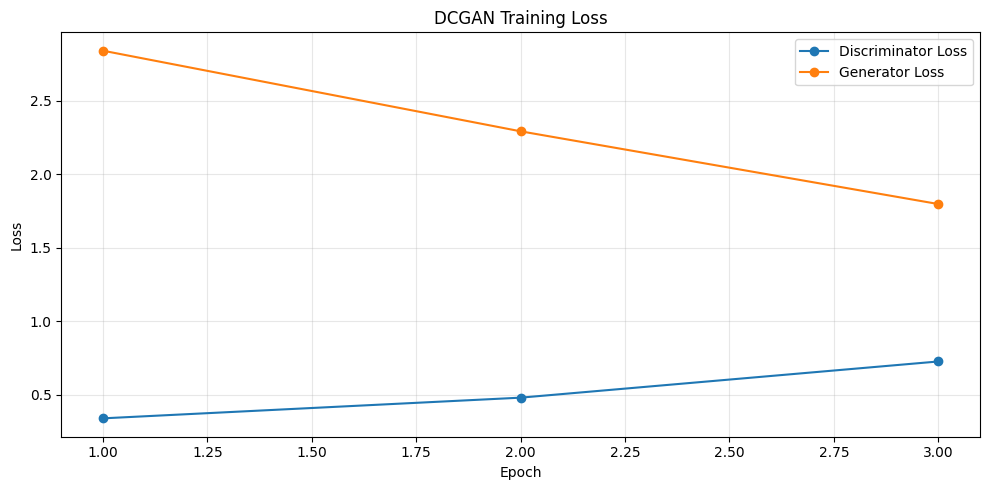

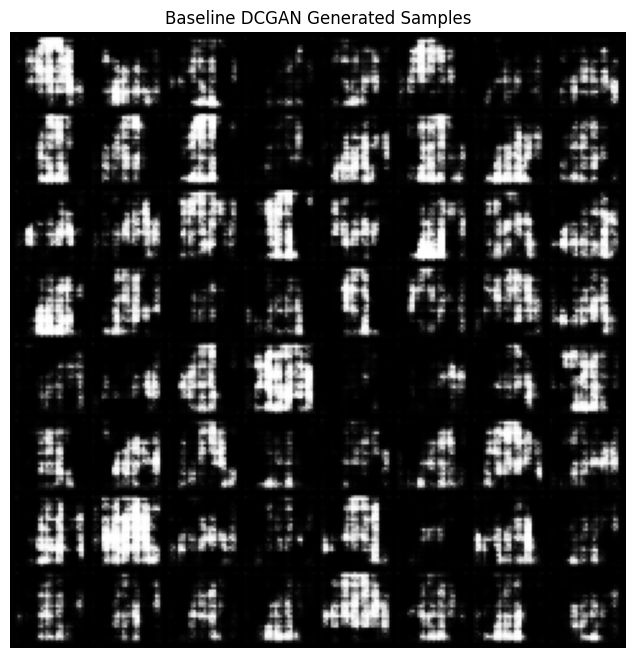

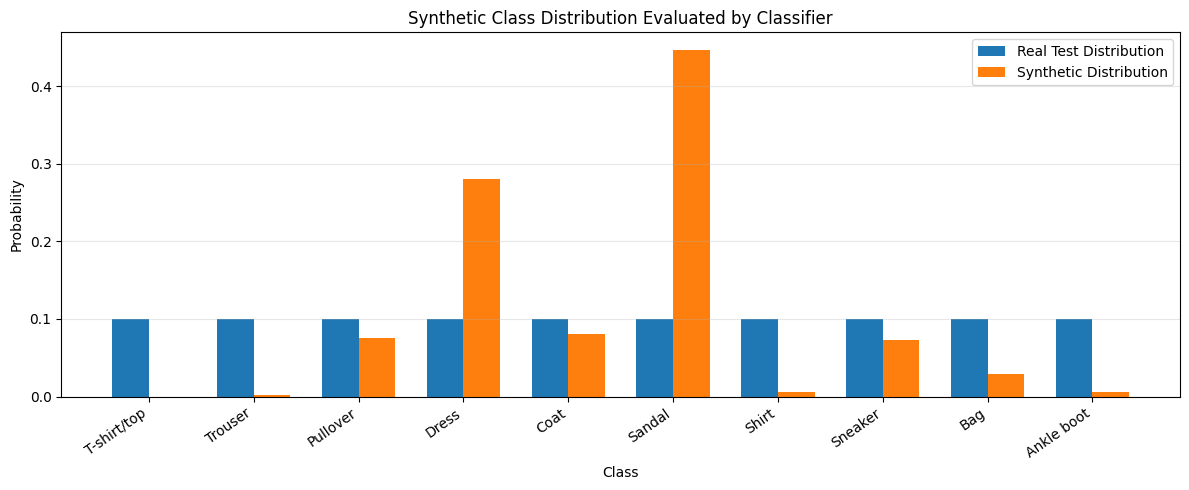

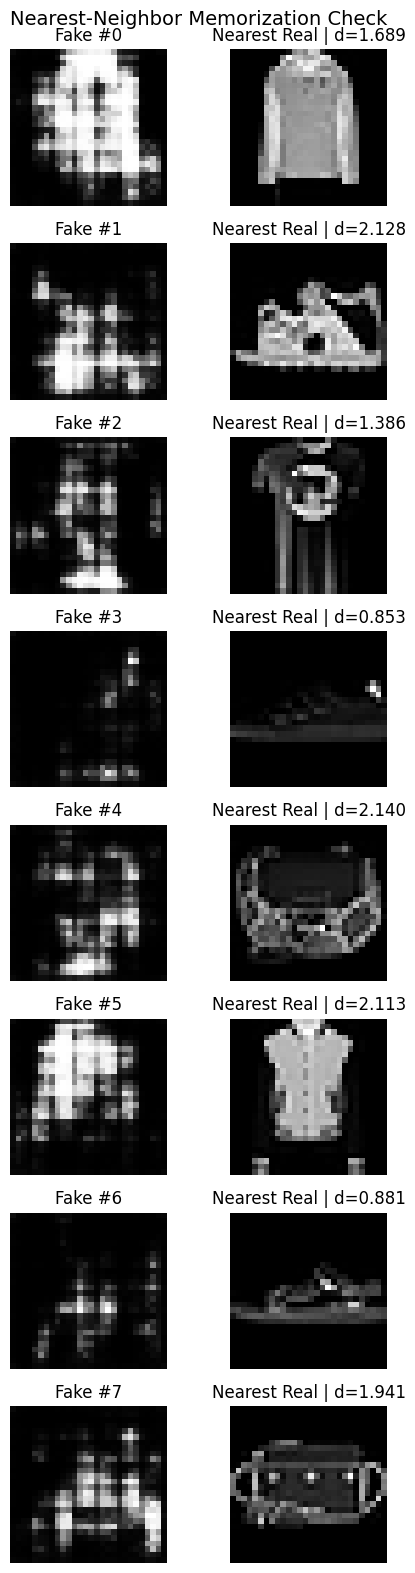


Integrated Generative Evaluation
Baseline generator saved to       : dcgan_fmnist_research_deployment/models/baseline_dcgan_generator_state_dict.pt
Baseline discriminator saved to   : dcgan_fmnist_research_deployment/models/baseline_dcgan_discriminator_state_dict.pt
Training history saved to         : dcgan_fmnist_research_deployment/outputs/dcgan_training_history.csv
Generated sample grid saved to    : dcgan_fmnist_research_deployment/figures/dcgan_baseline_generated_samples.png
Integrated metrics saved to       : dcgan_fmnist_research_deployment/outputs/baseline_dcgan_integrated_metrics.csv
Synthetic distribution saved to   : dcgan_fmnist_research_deployment/outputs/baseline_dcgan_synthetic_class_distribution.csv
Nearest-neighbor figure saved to  : dcgan_fmnist_research_deployment/figures/baseline_dcgan_nearest_neighbor_check.png
Mode collapse flag                : True


,epoch,discriminator_loss,generator_loss
0,1,0.339365,2.840346
1,2,0.480089,2.291990
2,3,0.726194,1.797343


,model_name,num_eval_samples,feature_fid,feature_kid,synthetic_entropy,synthetic_js_distance,dominant_class_id,dominant_class_name,dominant_class_probability,mean_fake_classifier_confidence,nearest_neighbor_distance_mean,nearest_neighbor_distance_min,nearest_neighbor_distance_std,mode_collapse_flag
0,baseline_dcgan,1000,13.671837,0.150744,1.483342,0.458147,5,Sandal,0.447,0.327548,1.825675,0.635288,0.421261,True


,class_id,class_name,real_probability,synthetic_probability,synthetic_count
0,0,T-shirt/top,0.1,0.000,0
1,1,Trouser,0.1,0.002,2
2,2,Pullover,0.1,0.076,76
3,3,Dress,0.1,0.280,280
4,4,Coat,0.1,0.081,81
5,5,Sandal,0.1,0.447,447
6,6,Shirt,0.1,0.006,6
7,7,Sneaker,0.1,0.073,73
8,8,Bag,0.1,0.029,29
9,9,Ankle boot,0.1,0.006,6


,diagnostic_aspect,value_or_interpretation
0,Feature-FID,13.6718
1,Feature-KID,0.150744
2,Synthetic entropy,1.4833
3,Synthetic JS distance,0.4581
4,Dominant synthetic class,Sandal
5,Dominant class probability,0.447
6,Mean fake classifier confidence,0.3275
7,Nearest-neighbor mean distance,1.8257
8,Mode collapse flag,True
9,Interpretation,Potential mode collapse is detected based on e...


In [11]:
# ============================================================
# Step 7 — DCGAN Training and Integrated Generative Evaluation
# ============================================================
# Deskripsi:
# Cell ini membangun baseline DCGAN, melakukan training generator dan discriminator,
# lalu mengevaluasi hasil generatif menggunakan pendekatan terpadu:
# 1. Loss generator dan discriminator
# 2. Visualisasi gambar sintetis
# 3. Feature-FID berbasis fitur classifier evaluator
# 4. Feature-KID berbasis polynomial MMD
# 5. Distribusi kelas sintetis
# 6. Entropy dan Jensen-Shannon distance
# 7. Nearest-neighbor memorization check
#
# Catatan integritas:
# - Loss GAN tidak dijadikan satu-satunya indikator keberhasilan.
# - Discriminator menghasilkan logit mentah karena memakai BCEWithLogitsLoss.
# - Gambar sintetis dinilai bersama metrik distribusional dan visual.

# ------------------------------------------------------------
# Validasi prasyarat dari cell sebelumnya.
# ------------------------------------------------------------

required_objects = [
    "CONFIG", "DEVICE", "MODEL_DIR", "OUTPUT_DIR", "FIGURE_DIR",
    "dcgan_train_loader", "classifier_model", "classifier_test_loader",
    "test_norm_subset", "CLASS_NAMES"
]

missing_objects = [name for name in required_objects if name not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        "Objek berikut belum tersedia dari cell sebelumnya: "
        + ", ".join(missing_objects)
        + ". Jalankan Cell 1 sampai Cell 6 secara berurutan terlebih dahulu."
    )

# ------------------------------------------------------------
# Inisialisasi bobot DCGAN.
# ------------------------------------------------------------

def dcgan_weights_init(module: nn.Module) -> None:
    """Menginisialisasi bobot convolution dan batch normalization untuk DCGAN."""
    classname = module.__class__.__name__

    if "Conv" in classname:
        if hasattr(module, "weight") and module.weight is not None:
            nn.init.normal_(module.weight.data, 0.0, 0.02)

    if "BatchNorm" in classname:
        if hasattr(module, "weight") and module.weight is not None:
            nn.init.normal_(module.weight.data, 1.0, 0.02)
        if hasattr(module, "bias") and module.bias is not None:
            nn.init.constant_(module.bias.data, 0.0)


# ------------------------------------------------------------
# Generator DCGAN untuk Fashion-MNIST 28x28 grayscale.
# ------------------------------------------------------------

class DCGANGenerator(nn.Module):
    """Generator DCGAN dengan output [B, 1, 28, 28]."""

    def __init__(self, latent_dim: int = 100, channels: int = 1):
        super().__init__()

        self.latent_dim = latent_dim

        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(inplace=True)
        )

        self.generator = nn.Sequential(
            nn.Unflatten(dim=1, unflattened_size=(128, 7, 7)),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        projected = self.project(z)
        generated = self.generator(projected)
        return generated


# ------------------------------------------------------------
# Discriminator DCGAN.
# Output berupa logit mentah, bukan probabilitas Sigmoid.
# BCEWithLogitsLoss sudah menggabungkan Sigmoid dan BCE secara numerik stabil.
# ------------------------------------------------------------

class DCGANDiscriminator(nn.Module):
    """Discriminator DCGAN dengan output logit [B]."""

    def __init__(self, channels: int = 1):
        super().__init__()

        self.discriminator = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = self.discriminator(x)
        return logits.view(-1)


# ------------------------------------------------------------
# Bangun model baseline DCGAN.
# ------------------------------------------------------------

generator = DCGANGenerator(
    latent_dim=CONFIG["latent_dim"],
    channels=CONFIG["channels"]
).to(DEVICE)

discriminator = DCGANDiscriminator(
    channels=CONFIG["channels"]
).to(DEVICE)

generator.apply(dcgan_weights_init)
discriminator.apply(dcgan_weights_init)

# ------------------------------------------------------------
# Sanity check bentuk tensor.
# ------------------------------------------------------------

with torch.no_grad():
    z_dummy = torch.randn(8, CONFIG["latent_dim"], device=DEVICE)
    fake_dummy = generator(z_dummy)
    disc_dummy = discriminator(fake_dummy)

assert fake_dummy.shape == torch.Size([8, 1, 28, 28]), (
    f"Output generator salah: {fake_dummy.shape}. Seharusnya [8, 1, 28, 28]."
)

assert disc_dummy.shape == torch.Size([8]), (
    f"Output discriminator salah: {disc_dummy.shape}. Seharusnya [8]."
)

# ------------------------------------------------------------
# Loss dan optimizer.
# ------------------------------------------------------------

adversarial_criterion = nn.BCEWithLogitsLoss()

optimizer_g = optim.Adam(
    generator.parameters(),
    lr=CONFIG["dcgan_lr_g"],
    betas=(CONFIG["beta1"], CONFIG["beta2"])
)

optimizer_d = optim.Adam(
    discriminator.parameters(),
    lr=CONFIG["dcgan_lr_d"],
    betas=(CONFIG["beta1"], CONFIG["beta2"])
)

# ------------------------------------------------------------
# Fungsi utilitas visualisasi dan sampling.
# ------------------------------------------------------------

def denormalize_image_tensor(x: torch.Tensor) -> torch.Tensor:
    """Mengubah citra dari rentang [-1, 1] ke rentang [0, 1]."""
    return torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


def generate_images(
    model_g: nn.Module,
    n_samples: int,
    latent_dim: int,
    device: torch.device,
    batch_size: int = 128
) -> torch.Tensor:
    """Menghasilkan citra sintetis dari generator."""
    model_g.eval()
    batches = []
    generated_count = 0

    with torch.no_grad():
        while generated_count < n_samples:
            current_batch = min(batch_size, n_samples - generated_count)
            z = torch.randn(current_batch, latent_dim, device=device)
            fake_images = model_g(z).detach().cpu()
            batches.append(fake_images)
            generated_count += current_batch

    return torch.cat(batches, dim=0)


# ------------------------------------------------------------
# Training baseline DCGAN.
# ------------------------------------------------------------

fixed_noise = torch.randn(64, CONFIG["latent_dim"], device=DEVICE)
dcgan_history = []

for epoch in range(1, CONFIG["dcgan_epochs"] + 1):
    generator.train()
    discriminator.train()

    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    total_samples = 0

    for real_images, _ in dcgan_train_loader:
        real_images = real_images.to(DEVICE)
        batch_size_current = real_images.size(0)

        real_targets = torch.ones(batch_size_current, device=DEVICE)
        fake_targets = torch.zeros(batch_size_current, device=DEVICE)

        # -------------------------
        # Train Discriminator
        # -------------------------
        optimizer_d.zero_grad(set_to_none=True)

        real_logits = discriminator(real_images)
        loss_d_real = adversarial_criterion(real_logits, real_targets)

        z = torch.randn(batch_size_current, CONFIG["latent_dim"], device=DEVICE)
        fake_images = generator(z)

        fake_logits = discriminator(fake_images.detach())
        loss_d_fake = adversarial_criterion(fake_logits, fake_targets)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_d.step()

        # -------------------------
        # Train Generator
        # -------------------------
        optimizer_g.zero_grad(set_to_none=True)

        fake_logits_for_g = discriminator(fake_images)
        loss_g = adversarial_criterion(fake_logits_for_g, real_targets)

        loss_g.backward()
        optimizer_g.step()

        epoch_d_loss += float(loss_d.item()) * batch_size_current
        epoch_g_loss += float(loss_g.item()) * batch_size_current
        total_samples += batch_size_current

    avg_d_loss = epoch_d_loss / total_samples
    avg_g_loss = epoch_g_loss / total_samples

    dcgan_history.append({
        "epoch": epoch,
        "discriminator_loss": avg_d_loss,
        "generator_loss": avg_g_loss
    })

    print(
        f"Epoch {epoch:03d} | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

    generator.eval()
    with torch.no_grad():
        fixed_fake = generator(fixed_noise).detach().cpu()

    grid_path = FIGURE_DIR / f"dcgan_generated_epoch_{epoch:03d}.png"
    utils.save_image(
        denormalize_image_tensor(fixed_fake),
        grid_path,
        nrow=8
    )

# ------------------------------------------------------------
# Simpan dan visualisasikan training history.
# ------------------------------------------------------------

dcgan_history_df = pd.DataFrame(dcgan_history)
dcgan_history_path = OUTPUT_DIR / "dcgan_training_history.csv"
dcgan_history_df.to_csv(dcgan_history_path, index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    dcgan_history_df["epoch"],
    dcgan_history_df["discriminator_loss"],
    marker="o",
    label="Discriminator Loss"
)
ax.plot(
    dcgan_history_df["epoch"],
    dcgan_history_df["generator_loss"],
    marker="o",
    label="Generator Loss"
)
ax.set_title("DCGAN Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3)
ax.legend()

dcgan_loss_fig_path = FIGURE_DIR / "dcgan_training_loss.png"
plt.tight_layout()
plt.savefig(dcgan_loss_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Siapkan real dan fake images untuk evaluasi.
# ------------------------------------------------------------

num_eval_samples = min(CONFIG["num_eval_samples"], len(test_norm_subset))

if num_eval_samples < 3:
    raise ValueError("num_eval_samples harus minimal 3 agar Feature-KID dapat dihitung.")

fake_eval_images = generate_images(
    model_g=generator,
    n_samples=num_eval_samples,
    latent_dim=CONFIG["latent_dim"],
    device=DEVICE,
    batch_size=CONFIG["batch_size"]
)

real_eval_batches = []
real_eval_labels = []

for images, labels in classifier_test_loader:
    real_eval_batches.append(images)
    real_eval_labels.append(labels)

real_eval_images = torch.cat(real_eval_batches, dim=0)[:num_eval_samples]
real_eval_labels = torch.cat(real_eval_labels, dim=0)[:num_eval_samples]

assert fake_eval_images.shape[1:] == torch.Size([1, 28, 28]), "Fake image shape tidak valid."
assert real_eval_images.shape[1:] == torch.Size([1, 28, 28]), "Real image shape tidak valid."

# ------------------------------------------------------------
# Simpan dan tampilkan sampel sintetis.
# ------------------------------------------------------------

fake_grid_fig_path = FIGURE_DIR / "dcgan_baseline_generated_samples.png"

utils.save_image(
    denormalize_image_tensor(fake_eval_images[:64]),
    fake_grid_fig_path,
    nrow=8
)

grid_image = Image.open(fake_grid_fig_path)
plt.figure(figsize=(8, 8))
plt.imshow(grid_image, cmap="gray")
plt.title("Baseline DCGAN Generated Samples")
plt.axis("off")
plt.show()

# ------------------------------------------------------------
# Ekstraksi fitur dan prediksi kelas sintetis dengan classifier evaluator.
# ------------------------------------------------------------

def extract_classifier_features(
    model: nn.Module,
    images: torch.Tensor,
    device: torch.device,
    batch_size: int = 128
) -> np.ndarray:
    """Mengambil fitur dari classifier evaluator."""
    model.eval()
    feature_batches = []

    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            batch = images[start:start + batch_size].to(device)
            features = model.extract_features(batch)
            feature_batches.append(features.detach().cpu().numpy())

    return np.concatenate(feature_batches, axis=0)


def predict_with_classifier(
    model: nn.Module,
    images: torch.Tensor,
    device: torch.device,
    batch_size: int = 128
) -> dict:
    """Menghasilkan prediksi kelas dan confidence dari classifier evaluator."""
    model.eval()
    prob_batches = []
    pred_batches = []

    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            batch = images[start:start + batch_size].to(device)
            logits = model(batch)
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            prob_batches.append(probabilities.detach().cpu().numpy())
            pred_batches.append(predictions.detach().cpu().numpy())

    probabilities_np = np.concatenate(prob_batches, axis=0)
    predictions_np = np.concatenate(pred_batches, axis=0)

    return {
        "probabilities": probabilities_np,
        "predictions": predictions_np,
        "confidence": probabilities_np.max(axis=1)
    }


real_features = extract_classifier_features(
    model=classifier_model,
    images=real_eval_images,
    device=DEVICE,
    batch_size=CONFIG["batch_size"]
)

fake_features = extract_classifier_features(
    model=classifier_model,
    images=fake_eval_images,
    device=DEVICE,
    batch_size=CONFIG["batch_size"]
)

fake_predictions = predict_with_classifier(
    model=classifier_model,
    images=fake_eval_images,
    device=DEVICE,
    batch_size=CONFIG["batch_size"]
)

# ------------------------------------------------------------
# Feature-FID dan Feature-KID.
# ------------------------------------------------------------

def compute_feature_fid(
    real_feat: np.ndarray,
    fake_feat: np.ndarray,
    eps: float = 1e-6
) -> float:
    """Menghitung Feature-FID sederhana dari fitur real dan fake."""
    real_feat = np.asarray(real_feat, dtype=np.float64)
    fake_feat = np.asarray(fake_feat, dtype=np.float64)

    mu_real = np.mean(real_feat, axis=0)
    mu_fake = np.mean(fake_feat, axis=0)

    cov_real = np.cov(real_feat, rowvar=False)
    cov_fake = np.cov(fake_feat, rowvar=False)

    cov_real = cov_real + np.eye(cov_real.shape[0]) * eps
    cov_fake = cov_fake + np.eye(cov_fake.shape[0]) * eps

    mean_diff = mu_real - mu_fake
    cov_mean = sqrtm(cov_real @ cov_fake)

    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real

    cov_mean = np.nan_to_num(cov_mean, nan=0.0, posinf=0.0, neginf=0.0)

    fid_value = mean_diff @ mean_diff + np.trace(
        cov_real + cov_fake - 2.0 * cov_mean
    )

    return float(max(fid_value, 0.0))


def polynomial_kernel(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Kernel polynomial untuk estimasi KID berbasis MMD."""
    feature_dim = x.shape[1]
    return ((x @ y.T) / feature_dim + 1.0) ** 3


def compute_feature_kid(real_feat: np.ndarray, fake_feat: np.ndarray) -> float:
    """Menghitung Feature-KID sederhana berbasis polynomial MMD."""
    real_feat = np.asarray(real_feat, dtype=np.float64)
    fake_feat = np.asarray(fake_feat, dtype=np.float64)

    n = real_feat.shape[0]
    m = fake_feat.shape[0]

    if n < 2 or m < 2:
        raise ValueError("Feature-KID membutuhkan minimal dua sampel real dan fake.")

    k_xx = polynomial_kernel(real_feat, real_feat)
    k_yy = polynomial_kernel(fake_feat, fake_feat)
    k_xy = polynomial_kernel(real_feat, fake_feat)

    sum_xx = (k_xx.sum() - np.trace(k_xx)) / (n * (n - 1))
    sum_yy = (k_yy.sum() - np.trace(k_yy)) / (m * (m - 1))
    mean_xy = k_xy.mean()

    return float(sum_xx + sum_yy - 2.0 * mean_xy)


feature_fid_value = compute_feature_fid(real_features, fake_features)
feature_kid_value = compute_feature_kid(real_features, fake_features)

# ------------------------------------------------------------
# Distribusi kelas sintetis, entropy, dan Jensen-Shannon distance.
# ------------------------------------------------------------

def entropy_from_probabilities(probabilities: np.ndarray, eps: float = 1e-12) -> float:
    """Menghitung entropy natural dari distribusi probabilitas."""
    p = np.asarray(probabilities, dtype=np.float64)
    p = np.clip(p, eps, 1.0)
    return float(-(p * np.log(p)).sum())


fake_class_counts = np.bincount(
    fake_predictions["predictions"],
    minlength=10
)
fake_class_prob = fake_class_counts / fake_class_counts.sum()

real_class_counts = np.bincount(
    real_eval_labels.detach().cpu().numpy(),
    minlength=10
)
real_class_prob = real_class_counts / real_class_counts.sum()

synthetic_entropy = entropy_from_probabilities(fake_class_prob)
synthetic_js_distance = float(jensenshannon(real_class_prob, fake_class_prob))

dominant_class_id = int(np.argmax(fake_class_prob))
dominant_class_prob = float(fake_class_prob[dominant_class_id])
mean_fake_confidence = float(np.mean(fake_predictions["confidence"]))

# ------------------------------------------------------------
# Nearest-neighbor memorization check.
# ------------------------------------------------------------

def compute_nearest_neighbor_distances(
    real_feat: np.ndarray,
    fake_feat: np.ndarray,
    max_items: int = 500
) -> dict:
    """Menghitung jarak nearest-neighbor fake-to-real dalam ruang fitur."""
    item_count = min(max_items, len(real_feat), len(fake_feat))

    real_limited = real_feat[:item_count]
    fake_limited = fake_feat[:item_count]

    distances_squared = (
        np.sum(fake_limited ** 2, axis=1, keepdims=True)
        - 2.0 * fake_limited @ real_limited.T
        + np.sum(real_limited ** 2, axis=1, keepdims=True).T
    )

    distances_squared = np.maximum(distances_squared, 0.0)

    nearest_indices = np.argmin(distances_squared, axis=1)
    nearest_distances = np.sqrt(np.min(distances_squared, axis=1))

    return {
        "nearest_indices": nearest_indices,
        "nearest_distances": nearest_distances,
        "item_count": item_count
    }


nn_result = compute_nearest_neighbor_distances(
    real_feat=real_features,
    fake_feat=fake_features,
    max_items=min(500, num_eval_samples)
)

nearest_distance_mean = float(np.mean(nn_result["nearest_distances"]))
nearest_distance_min = float(np.min(nn_result["nearest_distances"]))
nearest_distance_std = float(np.std(nn_result["nearest_distances"]))

# ------------------------------------------------------------
# Mode collapse heuristic.
# ------------------------------------------------------------

mode_collapse_flag = bool(
    synthetic_entropy < CONFIG["mode_collapse_entropy_threshold"]
    or dominant_class_prob > CONFIG["dominant_class_threshold"]
)

# ------------------------------------------------------------
# Simpan metrik evaluasi.
# ------------------------------------------------------------

generative_metrics = {
    "model_name": "baseline_dcgan",
    "num_eval_samples": int(num_eval_samples),
    "feature_fid": float(feature_fid_value),
    "feature_kid": float(feature_kid_value),
    "synthetic_entropy": float(synthetic_entropy),
    "synthetic_js_distance": float(synthetic_js_distance),
    "dominant_class_id": int(dominant_class_id),
    "dominant_class_name": CLASS_NAMES[dominant_class_id],
    "dominant_class_probability": float(dominant_class_prob),
    "mean_fake_classifier_confidence": float(mean_fake_confidence),
    "nearest_neighbor_distance_mean": float(nearest_distance_mean),
    "nearest_neighbor_distance_min": float(nearest_distance_min),
    "nearest_neighbor_distance_std": float(nearest_distance_std),
    "mode_collapse_flag": bool(mode_collapse_flag)
}

generative_metrics_df = pd.DataFrame([generative_metrics])

generative_metrics_path = OUTPUT_DIR / "baseline_dcgan_integrated_metrics.csv"
generative_metrics_df.to_csv(generative_metrics_path, index=False)

with open(
    OUTPUT_DIR / "baseline_dcgan_integrated_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(generative_metrics, f, indent=4, ensure_ascii=False)

synthetic_distribution_df = pd.DataFrame({
    "class_id": np.arange(10),
    "class_name": CLASS_NAMES,
    "real_probability": real_class_prob,
    "synthetic_probability": fake_class_prob,
    "synthetic_count": fake_class_counts
})

synthetic_distribution_path = OUTPUT_DIR / "baseline_dcgan_synthetic_class_distribution.csv"
synthetic_distribution_df.to_csv(synthetic_distribution_path, index=False)

# ------------------------------------------------------------
# Visualisasi distribusi kelas sintetis.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(10)
width = 0.35

ax.bar(x - width / 2, real_class_prob, width, label="Real Test Distribution")
ax.bar(x + width / 2, fake_class_prob, width, label="Synthetic Distribution")

ax.set_title("Synthetic Class Distribution Evaluated by Classifier")
ax.set_xlabel("Class")
ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.legend()

synthetic_dist_fig_path = FIGURE_DIR / "baseline_dcgan_synthetic_class_distribution.png"
plt.tight_layout()
plt.savefig(synthetic_dist_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Visualisasi nearest-neighbor pairs.
# ------------------------------------------------------------

pair_count = min(8, nn_result["item_count"])
real_limited_images = real_eval_images[:nn_result["item_count"]]
fake_limited_images = fake_eval_images[:nn_result["item_count"]]

fig, axes = plt.subplots(pair_count, 2, figsize=(5, pair_count * 2))

if pair_count == 1:
    axes = np.array([axes])

for row in range(pair_count):
    fake_img = denormalize_image_tensor(
        fake_limited_images[row]
    ).squeeze(0).numpy()

    nearest_real_idx = int(nn_result["nearest_indices"][row])

    real_img = denormalize_image_tensor(
        real_limited_images[nearest_real_idx]
    ).squeeze(0).numpy()

    axes[row, 0].imshow(fake_img, cmap="gray")
    axes[row, 0].set_title(f"Fake #{row}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(real_img, cmap="gray")
    axes[row, 1].set_title(
        f"Nearest Real | d={nn_result['nearest_distances'][row]:.3f}"
    )
    axes[row, 1].axis("off")

fig.suptitle("Nearest-Neighbor Memorization Check", fontsize=14)
nearest_neighbor_fig_path = FIGURE_DIR / "baseline_dcgan_nearest_neighbor_check.png"
plt.tight_layout()
plt.savefig(nearest_neighbor_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Simpan model baseline.
# ------------------------------------------------------------

baseline_generator_path = MODEL_DIR / "baseline_dcgan_generator_state_dict.pt"
baseline_discriminator_path = MODEL_DIR / "baseline_dcgan_discriminator_state_dict.pt"

torch.save(
    {
        "model_state_dict": generator.state_dict(),
        "latent_dim": CONFIG["latent_dim"],
        "channels": CONFIG["channels"],
        "config": CONFIG,
        "metrics": generative_metrics
    },
    baseline_generator_path
)

torch.save(
    {
        "model_state_dict": discriminator.state_dict(),
        "channels": CONFIG["channels"],
        "config": CONFIG
    },
    baseline_discriminator_path
)

# ------------------------------------------------------------
# Insight otomatis berbasis metrik.
# ------------------------------------------------------------

if mode_collapse_flag:
    generative_insight = (
        "Potential mode collapse is detected based on entropy or dominant-class probability. "
        "The improved DCGAN stage should apply stabilization techniques."
    )
else:
    generative_insight = (
        "No strong mode-collapse indication is detected under the configured heuristic. "
        "Nevertheless, visual inspection and feature-based metrics must be interpreted together."
    )

generative_insight_df = pd.DataFrame({
    "diagnostic_aspect": [
        "Feature-FID",
        "Feature-KID",
        "Synthetic entropy",
        "Synthetic JS distance",
        "Dominant synthetic class",
        "Dominant class probability",
        "Mean fake classifier confidence",
        "Nearest-neighbor mean distance",
        "Mode collapse flag",
        "Interpretation"
    ],
    "value_or_interpretation": [
        round(feature_fid_value, 4),
        round(feature_kid_value, 6),
        round(synthetic_entropy, 4),
        round(synthetic_js_distance, 4),
        CLASS_NAMES[dominant_class_id],
        round(dominant_class_prob, 4),
        round(mean_fake_confidence, 4),
        round(nearest_distance_mean, 4),
        bool(mode_collapse_flag),
        generative_insight
    ]
})

generative_insight_path = OUTPUT_DIR / "baseline_dcgan_generative_insights.csv"
generative_insight_df.to_csv(generative_insight_path, index=False)

print("\nIntegrated Generative Evaluation")
print("=" * 70)
print(f"Baseline generator saved to       : {baseline_generator_path}")
print(f"Baseline discriminator saved to   : {baseline_discriminator_path}")
print(f"Training history saved to         : {dcgan_history_path}")
print(f"Generated sample grid saved to    : {fake_grid_fig_path}")
print(f"Integrated metrics saved to       : {generative_metrics_path}")
print(f"Synthetic distribution saved to   : {synthetic_distribution_path}")
print(f"Nearest-neighbor figure saved to  : {nearest_neighbor_fig_path}")
print(f"Mode collapse flag                : {mode_collapse_flag}")
print("=" * 70)

display(dcgan_history_df)
display(generative_metrics_df)
display(synthetic_distribution_df)
display(generative_insight_df)


Logical Revision Plan


,revision_component,description
0,Selected revision,Stabilized DCGAN
1,Technique 1,Label smoothing
2,Technique 2,Instance noise
3,Technique 3,Light TTUR through lower discriminator learnin...
4,Primary reasons,Mode collapse heuristic was triggered. | Synth...


Improved Epoch 001 | D Loss: 0.7441 | G Loss: 1.7360 | Noise: 0.0500
Improved Epoch 002 | D Loss: 0.8980 | G Loss: 1.3641 | Noise: 0.0250


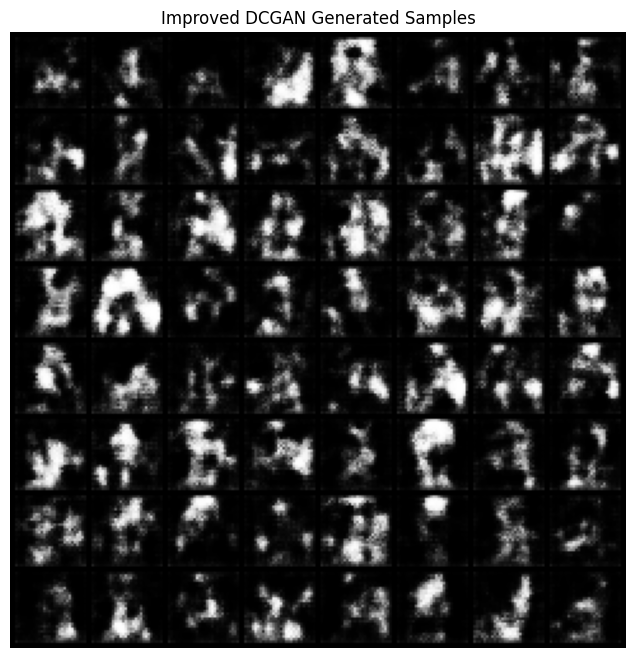

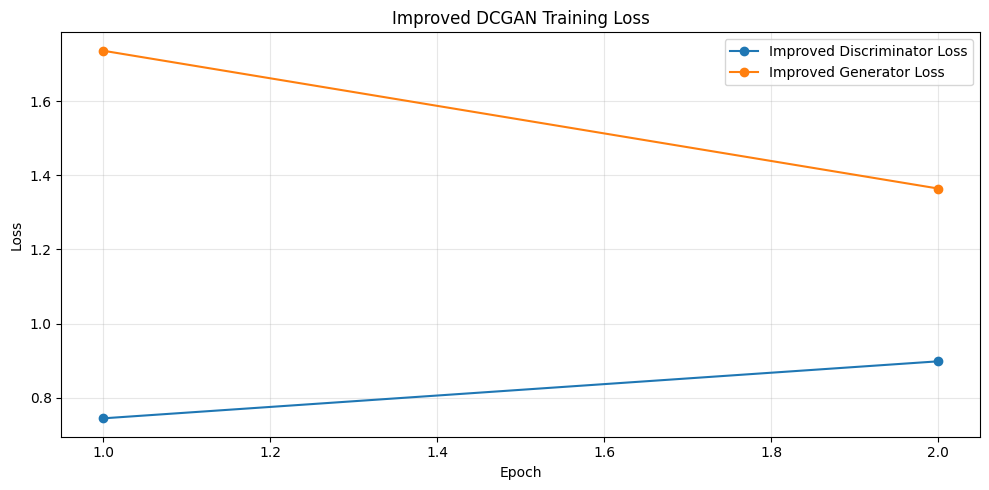


Improved DCGAN Evaluation
Revision plan saved to           : dcgan_fmnist_research_deployment/outputs/logical_revision_plan.json
Improved history saved to        : dcgan_fmnist_research_deployment/outputs/improved_dcgan_training_history.csv
Improved metrics saved to        : dcgan_fmnist_research_deployment/outputs/improved_dcgan_integrated_metrics.csv
Comparison saved to              : dcgan_fmnist_research_deployment/outputs/baseline_vs_improved_generative_comparison.csv
Revision summary saved to        : dcgan_fmnist_research_deployment/outputs/improved_dcgan_revision_summary.csv
Improved generator saved to      : dcgan_fmnist_research_deployment/models/improved_dcgan_generator_state_dict.pt
Improved discriminator saved to  : dcgan_fmnist_research_deployment/models/improved_dcgan_discriminator_state_dict.pt
Overall interpretation           : Improved DCGAN shows a stronger overall pattern under the integrated evaluation protocol.


,epoch,discriminator_loss,generator_loss,instance_noise_std,real_label_smooth,lr_g,lr_d
0,1,0.744136,1.736001,0.050,0.9,0.0002,0.0001
1,2,0.898012,1.364110,0.025,0.9,0.0002,0.0001


,model_name,num_eval_samples,feature_fid,feature_kid,synthetic_entropy,synthetic_js_distance,dominant_class_id,dominant_class_name,dominant_class_probability,mean_fake_classifier_confidence,nearest_neighbor_distance_mean,nearest_neighbor_distance_min,nearest_neighbor_distance_std,mode_collapse_flag
0,improved_dcgan,1000,17.213054,0.198218,1.628046,0.427891,7,Sneaker,0.351,0.288164,1.705983,0.501421,0.499107,True


,model_name,num_eval_samples,feature_fid,feature_kid,synthetic_entropy,synthetic_js_distance,dominant_class_id,dominant_class_name,dominant_class_probability,mean_fake_classifier_confidence,nearest_neighbor_distance_mean,nearest_neighbor_distance_min,nearest_neighbor_distance_std,mode_collapse_flag
0,baseline_dcgan,1000,13.671837,0.150744,1.483342,0.458147,5,Sandal,0.447,0.327548,1.825675,0.635288,0.421261,True
1,improved_dcgan,1000,17.213054,0.198218,1.628046,0.427891,7,Sneaker,0.351,0.288164,1.705983,0.501421,0.499107,True


,criterion,result
0,feature_fid_improved,False
1,synthetic_js_distance_improved,True
2,synthetic_entropy_improved,True
3,dominant_class_probability_improved,True
4,overall_interpretation,Improved DCGAN shows a stronger overall patter...


In [12]:
# ============================================================
# Step 8 — Logical Revision and Improved DCGAN
# ============================================================
# Deskripsi:
# Cell ini melakukan revisi logis berdasarkan hasil evaluasi baseline DCGAN.
# Jika baseline menunjukkan indikasi mode collapse atau distribusi sintetis
# terlalu dominan pada kelas tertentu, maka program menjalankan Improved DCGAN.
#
# Strategi revisi:
# 1. Label smoothing: label real tidak selalu 1.0, tetapi 0.9.
# 2. Instance noise: noise kecil ditambahkan pada input discriminator.
# 3. TTUR ringan: learning rate discriminator dibuat lebih kecil dari generator.
#
# Prinsip integritas:
# - Revisi dilakukan berdasarkan hasil Cell 7, bukan asumsi.
# - Hasil improved model dibandingkan ulang dengan protokol evaluasi yang sama.
# - Jika improved model tidak membaik, laporan harus menyatakan apa adanya.

# ------------------------------------------------------------
# Validasi prasyarat dari Cell 7.
# ------------------------------------------------------------

required_step8_objects = [
    "generator", "discriminator", "generative_metrics",
    "mode_collapse_flag", "DCGANGenerator", "DCGANDiscriminator",
    "dcgan_weights_init", "generate_images", "denormalize_image_tensor",
    "extract_classifier_features", "predict_with_classifier",
    "compute_feature_fid", "compute_feature_kid",
    "entropy_from_probabilities", "compute_nearest_neighbor_distances",
    "real_eval_images", "real_eval_labels", "real_features",
    "classifier_model", "dcgan_train_loader"
]

missing_step8_objects = [name for name in required_step8_objects if name not in globals()]

if len(missing_step8_objects) > 0:
    raise NameError(
        "Objek berikut belum tersedia dari Cell 7: "
        + ", ".join(missing_step8_objects)
        + ". Jalankan Cell 7 terlebih dahulu sampai output Integrated Generative Evaluation muncul."
    )

# ------------------------------------------------------------
# Fungsi pelatihan Improved DCGAN.
# Pola adversarial training tetap sama seperti baseline,
# tetapi ditambahkan teknik stabilisasi ringan.
# ------------------------------------------------------------

def train_improved_dcgan(
    train_loader: DataLoader,
    latent_dim: int,
    channels: int,
    device: torch.device,
    epochs: int,
    lr_g: float,
    lr_d: float,
    beta1: float,
    beta2: float,
    instance_noise_std: float = 0.05,
    real_label_smooth: float = 0.90
) -> dict:
    """
    Melatih Improved DCGAN dengan label smoothing, instance noise,
    dan TTUR ringan.

    Output:
    - generator
    - discriminator
    - training_history_df
    """

    improved_g = DCGANGenerator(
        latent_dim=latent_dim,
        channels=channels
    ).to(device)

    improved_d = DCGANDiscriminator(
        channels=channels
    ).to(device)

    improved_g.apply(dcgan_weights_init)
    improved_d.apply(dcgan_weights_init)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_g_improved = optim.Adam(
        improved_g.parameters(),
        lr=lr_g,
        betas=(beta1, beta2)
    )

    optimizer_d_improved = optim.Adam(
        improved_d.parameters(),
        lr=lr_d,
        betas=(beta1, beta2)
    )

    history = []
    fixed_noise_improved = torch.randn(64, latent_dim, device=device)

    for epoch in range(1, epochs + 1):
        improved_g.train()
        improved_d.train()

        epoch_d_loss = 0.0
        epoch_g_loss = 0.0
        total_samples = 0

        # Noise diturunkan perlahan agar stabilisasi kuat di awal dan lebih kecil di akhir.
        current_noise_std = instance_noise_std * max(0.0, 1.0 - (epoch - 1) / max(epochs, 1))

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            current_batch_size = real_images.size(0)

            real_targets = torch.full(
                size=(current_batch_size,),
                fill_value=real_label_smooth,
                device=device
            )

            fake_targets = torch.zeros(
                current_batch_size,
                device=device
            )

            # ------------------------------------------------
            # Train Discriminator
            # ------------------------------------------------
            optimizer_d_improved.zero_grad(set_to_none=True)

            if current_noise_std > 0:
                real_input = real_images + current_noise_std * torch.randn_like(real_images)
                real_input = torch.clamp(real_input, -1.0, 1.0)
            else:
                real_input = real_images

            real_logits = improved_d(real_input)
            loss_d_real = criterion(real_logits, real_targets)

            z = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = improved_g(z)

            if current_noise_std > 0:
                fake_input = fake_images.detach() + current_noise_std * torch.randn_like(fake_images)
                fake_input = torch.clamp(fake_input, -1.0, 1.0)
            else:
                fake_input = fake_images.detach()

            fake_logits = improved_d(fake_input)
            loss_d_fake = criterion(fake_logits, fake_targets)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer_d_improved.step()

            # ------------------------------------------------
            # Train Generator
            # ------------------------------------------------
            optimizer_g_improved.zero_grad(set_to_none=True)

            fake_logits_for_g = improved_d(fake_images)
            loss_g = criterion(fake_logits_for_g, real_targets)

            loss_g.backward()
            optimizer_g_improved.step()

            epoch_d_loss += float(loss_d.item()) * current_batch_size
            epoch_g_loss += float(loss_g.item()) * current_batch_size
            total_samples += current_batch_size

        avg_d_loss = epoch_d_loss / total_samples
        avg_g_loss = epoch_g_loss / total_samples

        history.append({
            "epoch": epoch,
            "discriminator_loss": avg_d_loss,
            "generator_loss": avg_g_loss,
            "instance_noise_std": current_noise_std,
            "real_label_smooth": real_label_smooth,
            "lr_g": lr_g,
            "lr_d": lr_d
        })

        print(
            f"Improved Epoch {epoch:03d} | "
            f"D Loss: {avg_d_loss:.4f} | "
            f"G Loss: {avg_g_loss:.4f} | "
            f"Noise: {current_noise_std:.4f}"
        )

        improved_g.eval()
        with torch.no_grad():
            fixed_fake = improved_g(fixed_noise_improved).detach().cpu()

        improved_grid_path = FIGURE_DIR / f"improved_dcgan_generated_epoch_{epoch:03d}.png"
        utils.save_image(
            denormalize_image_tensor(fixed_fake),
            improved_grid_path,
            nrow=8
        )

    history_df = pd.DataFrame(history)

    return {
        "generator": improved_g,
        "discriminator": improved_d,
        "history_df": history_df
    }


# ------------------------------------------------------------
# Fungsi evaluasi generator dengan protokol sama seperti baseline.
# ------------------------------------------------------------

def evaluate_generator_integrated(
    model_g: nn.Module,
    model_name: str,
    real_images_reference: torch.Tensor,
    real_labels_reference: torch.Tensor,
    real_features_reference: np.ndarray,
    classifier: nn.Module,
    device: torch.device,
    num_samples: int,
    latent_dim: int,
    batch_size: int
) -> dict:
    """
    Mengevaluasi generator menggunakan protokol terpadu yang sama
    dengan baseline DCGAN.
    """

    fake_images = generate_images(
        model_g=model_g,
        n_samples=num_samples,
        latent_dim=latent_dim,
        device=device,
        batch_size=batch_size
    )

    fake_features_eval = extract_classifier_features(
        model=classifier,
        images=fake_images,
        device=device,
        batch_size=batch_size
    )

    fake_preds_eval = predict_with_classifier(
        model=classifier,
        images=fake_images,
        device=device,
        batch_size=batch_size
    )

    fid_value = compute_feature_fid(
        real_features_reference,
        fake_features_eval
    )

    kid_value = compute_feature_kid(
        real_features_reference,
        fake_features_eval
    )

    fake_class_counts_eval = np.bincount(
        fake_preds_eval["predictions"],
        minlength=10
    )

    fake_class_prob_eval = fake_class_counts_eval / fake_class_counts_eval.sum()

    real_class_counts_eval = np.bincount(
        real_labels_reference.detach().cpu().numpy(),
        minlength=10
    )

    real_class_prob_eval = real_class_counts_eval / real_class_counts_eval.sum()

    entropy_value = entropy_from_probabilities(fake_class_prob_eval)
    js_distance_value = float(jensenshannon(real_class_prob_eval, fake_class_prob_eval))

    dominant_id = int(np.argmax(fake_class_prob_eval))
    dominant_prob = float(fake_class_prob_eval[dominant_id])

    nn_eval = compute_nearest_neighbor_distances(
        real_feat=real_features_reference,
        fake_feat=fake_features_eval,
        max_items=min(500, num_samples)
    )

    nn_mean = float(np.mean(nn_eval["nearest_distances"]))
    nn_min = float(np.min(nn_eval["nearest_distances"]))
    nn_std = float(np.std(nn_eval["nearest_distances"]))

    collapse_flag = bool(
        entropy_value < CONFIG["mode_collapse_entropy_threshold"]
        or dominant_prob > CONFIG["dominant_class_threshold"]
    )

    metrics = {
        "model_name": model_name,
        "num_eval_samples": int(num_samples),
        "feature_fid": float(fid_value),
        "feature_kid": float(kid_value),
        "synthetic_entropy": float(entropy_value),
        "synthetic_js_distance": float(js_distance_value),
        "dominant_class_id": int(dominant_id),
        "dominant_class_name": CLASS_NAMES[dominant_id],
        "dominant_class_probability": float(dominant_prob),
        "mean_fake_classifier_confidence": float(np.mean(fake_preds_eval["confidence"])),
        "nearest_neighbor_distance_mean": float(nn_mean),
        "nearest_neighbor_distance_min": float(nn_min),
        "nearest_neighbor_distance_std": float(nn_std),
        "mode_collapse_flag": bool(collapse_flag)
    }

    distribution_df = pd.DataFrame({
        "class_id": np.arange(10),
        "class_name": CLASS_NAMES,
        "real_probability": real_class_prob_eval,
        "synthetic_probability": fake_class_prob_eval,
        "synthetic_count": fake_class_counts_eval
    })

    return {
        "fake_images": fake_images,
        "fake_features": fake_features_eval,
        "fake_predictions": fake_preds_eval,
        "metrics": metrics,
        "distribution_df": distribution_df
    }


# ------------------------------------------------------------
# Diagnosis revisi berdasarkan hasil baseline.
# ------------------------------------------------------------

revision_reasons = []

if bool(generative_metrics["mode_collapse_flag"]):
    revision_reasons.append("Mode collapse heuristic was triggered.")

if float(generative_metrics["dominant_class_probability"]) > CONFIG["dominant_class_threshold"]:
    revision_reasons.append("Synthetic distribution is dominated by one class.")

if float(generative_metrics["synthetic_entropy"]) < CONFIG["mode_collapse_entropy_threshold"]:
    revision_reasons.append("Synthetic entropy is below the configured threshold.")

if len(revision_reasons) == 0:
    revision_reasons.append(
        "No severe collapse signal was detected, but improved DCGAN is still trained for controlled comparison."
    )

revision_plan = {
    "selected_revision": "Stabilized DCGAN",
    "techniques": [
        "Label smoothing",
        "Instance noise",
        "Light TTUR through lower discriminator learning rate"
    ],
    "revision_reasons": revision_reasons
}

revision_plan_path = OUTPUT_DIR / "logical_revision_plan.json"

with open(revision_plan_path, "w", encoding="utf-8") as f:
    json.dump(revision_plan, f, indent=4, ensure_ascii=False)

revision_plan_df = pd.DataFrame({
    "revision_component": [
        "Selected revision",
        "Technique 1",
        "Technique 2",
        "Technique 3",
        "Primary reasons"
    ],
    "description": [
        revision_plan["selected_revision"],
        revision_plan["techniques"][0],
        revision_plan["techniques"][1],
        revision_plan["techniques"][2],
        " | ".join(revision_reasons)
    ]
})

revision_plan_csv_path = OUTPUT_DIR / "logical_revision_plan.csv"
revision_plan_df.to_csv(revision_plan_csv_path, index=False)

print("\nLogical Revision Plan")
print("=" * 70)
display(revision_plan_df)

# ------------------------------------------------------------
# Train Improved DCGAN.
# Adam tetap digunakan sebagai optimizer karena mendukung learning rate
# dan parameter beta yang eksplisit untuk eksperimen adversarial.
# ------------------------------------------------------------

improved_result = train_improved_dcgan(
    train_loader=dcgan_train_loader,
    latent_dim=CONFIG["latent_dim"],
    channels=CONFIG["channels"],
    device=DEVICE,
    epochs=CONFIG["improved_dcgan_epochs"],
    lr_g=CONFIG["improved_lr_g"],
    lr_d=CONFIG["improved_lr_d"],
    beta1=CONFIG["beta1"],
    beta2=CONFIG["beta2"],
    instance_noise_std=0.05,
    real_label_smooth=0.90
)

improved_generator = improved_result["generator"]
improved_discriminator = improved_result["discriminator"]
improved_history_df = improved_result["history_df"]

improved_history_path = OUTPUT_DIR / "improved_dcgan_training_history.csv"
improved_history_df.to_csv(improved_history_path, index=False)

# ------------------------------------------------------------
# Evaluasi Improved DCGAN dengan protokol yang sama.
# ------------------------------------------------------------

improved_eval = evaluate_generator_integrated(
    model_g=improved_generator,
    model_name="improved_dcgan",
    real_images_reference=real_eval_images,
    real_labels_reference=real_eval_labels,
    real_features_reference=real_features,
    classifier=classifier_model,
    device=DEVICE,
    num_samples=num_eval_samples,
    latent_dim=CONFIG["latent_dim"],
    batch_size=CONFIG["batch_size"]
)

improved_metrics = improved_eval["metrics"]
improved_metrics_df = pd.DataFrame([improved_metrics])

improved_metrics_path = OUTPUT_DIR / "improved_dcgan_integrated_metrics.csv"
improved_metrics_df.to_csv(improved_metrics_path, index=False)

with open(OUTPUT_DIR / "improved_dcgan_integrated_metrics.json", "w", encoding="utf-8") as f:
    json.dump(improved_metrics, f, indent=4, ensure_ascii=False)

improved_distribution_path = OUTPUT_DIR / "improved_dcgan_synthetic_class_distribution.csv"
improved_eval["distribution_df"].to_csv(improved_distribution_path, index=False)

# ------------------------------------------------------------
# Simpan visualisasi improved generated samples.
# ------------------------------------------------------------

improved_fake_grid_path = FIGURE_DIR / "improved_dcgan_generated_samples.png"

utils.save_image(
    denormalize_image_tensor(improved_eval["fake_images"][:64]),
    improved_fake_grid_path,
    nrow=8
)

improved_grid_image = Image.open(improved_fake_grid_path)
plt.figure(figsize=(8, 8))
plt.imshow(improved_grid_image, cmap="gray")
plt.title("Improved DCGAN Generated Samples")
plt.axis("off")
plt.show()

# ------------------------------------------------------------
# Plot loss improved.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    improved_history_df["epoch"],
    improved_history_df["discriminator_loss"],
    marker="o",
    label="Improved Discriminator Loss"
)
ax.plot(
    improved_history_df["epoch"],
    improved_history_df["generator_loss"],
    marker="o",
    label="Improved Generator Loss"
)
ax.set_title("Improved DCGAN Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3)
ax.legend()

improved_loss_fig_path = FIGURE_DIR / "improved_dcgan_training_loss.png"
plt.tight_layout()
plt.savefig(improved_loss_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Bandingkan baseline vs improved.
# Arah interpretasi:
# - Feature-FID lebih kecil lebih baik.
# - Feature-KID lebih kecil lebih baik.
# - JS distance lebih kecil lebih baik.
# - Entropy lebih tinggi cenderung lebih baik untuk diversity kelas.
# - Dominant class probability lebih kecil cenderung lebih baik.
# ------------------------------------------------------------

comparison_df = pd.DataFrame([
    generative_metrics,
    improved_metrics
])

comparison_path = OUTPUT_DIR / "baseline_vs_improved_generative_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

baseline_fid = float(generative_metrics["feature_fid"])
improved_fid = float(improved_metrics["feature_fid"])

baseline_js = float(generative_metrics["synthetic_js_distance"])
improved_js = float(improved_metrics["synthetic_js_distance"])

baseline_entropy = float(generative_metrics["synthetic_entropy"])
improved_entropy = float(improved_metrics["synthetic_entropy"])

baseline_dominance = float(generative_metrics["dominant_class_probability"])
improved_dominance = float(improved_metrics["dominant_class_probability"])

improvement_votes = {
    "feature_fid_improved": improved_fid < baseline_fid,
    "synthetic_js_distance_improved": improved_js < baseline_js,
    "synthetic_entropy_improved": improved_entropy > baseline_entropy,
    "dominant_class_probability_improved": improved_dominance < baseline_dominance
}

improvement_score = int(sum(improvement_votes.values()))

if improvement_score >= 3:
    improvement_interpretation = (
        "Improved DCGAN shows a stronger overall pattern under the integrated evaluation protocol."
    )
elif improvement_score == 2:
    improvement_interpretation = (
        "Improved DCGAN shows mixed but partially supportive evidence."
    )
else:
    improvement_interpretation = (
        "Improved DCGAN does not show consistent improvement under the current lightweight setting."
    )

improvement_summary_df = pd.DataFrame({
    "criterion": list(improvement_votes.keys()) + ["overall_interpretation"],
    "result": list(improvement_votes.values()) + [improvement_interpretation]
})

improvement_summary_path = OUTPUT_DIR / "improved_dcgan_revision_summary.csv"
improvement_summary_df.to_csv(improvement_summary_path, index=False)

# ------------------------------------------------------------
# Simpan improved model.
# ------------------------------------------------------------

improved_generator_path = MODEL_DIR / "improved_dcgan_generator_state_dict.pt"
improved_discriminator_path = MODEL_DIR / "improved_dcgan_discriminator_state_dict.pt"

torch.save(
    {
        "model_state_dict": improved_generator.state_dict(),
        "latent_dim": CONFIG["latent_dim"],
        "channels": CONFIG["channels"],
        "config": CONFIG,
        "metrics": improved_metrics,
        "revision_plan": revision_plan
    },
    improved_generator_path
)

torch.save(
    {
        "model_state_dict": improved_discriminator.state_dict(),
        "channels": CONFIG["channels"],
        "config": CONFIG,
        "revision_plan": revision_plan
    },
    improved_discriminator_path
)

print("\nImproved DCGAN Evaluation")
print("=" * 70)
print(f"Revision plan saved to           : {revision_plan_path}")
print(f"Improved history saved to        : {improved_history_path}")
print(f"Improved metrics saved to        : {improved_metrics_path}")
print(f"Comparison saved to              : {comparison_path}")
print(f"Revision summary saved to        : {improvement_summary_path}")
print(f"Improved generator saved to      : {improved_generator_path}")
print(f"Improved discriminator saved to  : {improved_discriminator_path}")
print(f"Overall interpretation           : {improvement_interpretation}")
print("=" * 70)

display(improved_history_df)
display(improved_metrics_df)
display(comparison_df)
display(improvement_summary_df)

In [13]:
# ============================================================
# Step 9 — Save Final Model Artifacts with Joblib
# ============================================================
# Deskripsi:
# Cell ini menyimpan artefak final penelitian dan deployment.
# Model PyTorch disimpan dalam format state_dict (.pt),
# sedangkan metadata, konfigurasi, dan ringkasan hasil disimpan
# dalam format .joblib dan .json.
#
# Prinsip integritas:
# 1. Artefak disimpan dalam satu folder proyek.
# 2. Model tidak disimpan sebagai klaim hasil terbaik tanpa evaluasi.
# 3. Metadata menyimpan konfigurasi, metrik baseline, metrik improved,
#    dan interpretasi agar hasil dapat diaudit ulang.
# 4. File joblib hanya boleh dimuat dari sumber tepercaya.

# ------------------------------------------------------------
# Validasi prasyarat dari Cell 8.
# ------------------------------------------------------------

required_step9_objects = [
    "classifier_model",
    "generator",
    "discriminator",
    "improved_generator",
    "improved_discriminator",
    "generative_metrics",
    "improved_metrics",
    "comparison_df",
    "improvement_summary_df",
    "classifier_diagnostic_df",
    "revision_plan",
    "CONFIG",
    "CLASS_NAMES",
    "MODEL_DIR",
    "OUTPUT_DIR",
    "REPORT_DIR",
    "PROJECT_DIR"
]

missing_step9_objects = [
    name for name in required_step9_objects
    if name not in globals()
]

if len(missing_step9_objects) > 0:
    raise NameError(
        "Objek berikut belum tersedia dari cell sebelumnya: "
        + ", ".join(missing_step9_objects)
        + ". Jalankan Cell 1 sampai Cell 8 secara berurutan terlebih dahulu."
    )

# ------------------------------------------------------------
# Menentukan generator final secara logis.
# Pilihan tidak didasarkan pada asumsi, tetapi berdasarkan ringkasan
# perbandingan baseline vs improved.
# ------------------------------------------------------------

if "improvement_score" in globals():
    final_model_name = "improved_dcgan" if improvement_score >= 2 else "baseline_dcgan"
else:
    # Fallback aman: jika improvement_score belum ada, pilih improved
    # hanya jika FID improved lebih rendah dari baseline.
    final_model_name = (
        "improved_dcgan"
        if float(improved_metrics["feature_fid"]) < float(generative_metrics["feature_fid"])
        else "baseline_dcgan"
    )

if final_model_name == "improved_dcgan":
    final_generator = improved_generator
    final_discriminator = improved_discriminator
    final_metrics = improved_metrics
else:
    final_generator = generator
    final_discriminator = discriminator
    final_metrics = generative_metrics

# ------------------------------------------------------------
# Simpan state_dict final generator dan discriminator.
# ------------------------------------------------------------

final_generator_pt_path = MODEL_DIR / "final_dcgan_generator_state_dict.pt"
final_discriminator_pt_path = MODEL_DIR / "final_dcgan_discriminator_state_dict.pt"

torch.save(
    {
        "model_name": final_model_name,
        "model_state_dict": final_generator.state_dict(),
        "latent_dim": CONFIG["latent_dim"],
        "channels": CONFIG["channels"],
        "class_names": CLASS_NAMES,
        "config": CONFIG,
        "metrics": final_metrics,
        "created_at": datetime.now().isoformat()
    },
    final_generator_pt_path
)

torch.save(
    {
        "model_name": final_model_name,
        "model_state_dict": final_discriminator.state_dict(),
        "channels": CONFIG["channels"],
        "class_names": CLASS_NAMES,
        "config": CONFIG,
        "metrics": final_metrics,
        "created_at": datetime.now().isoformat()
    },
    final_discriminator_pt_path
)

# ------------------------------------------------------------
# Simpan classifier evaluator final.
# Classifier disimpan kembali sebagai artefak final karena dibutuhkan
# untuk smoke test dan dashboard Streamlit.
# ------------------------------------------------------------

final_classifier_pt_path = MODEL_DIR / "final_classifier_evaluator_state_dict.pt"

torch.save(
    {
        "model_name": "fashion_mnist_classifier_evaluator",
        "model_state_dict": classifier_model.state_dict(),
        "class_names": CLASS_NAMES,
        "config": CONFIG,
        "classifier_diagnostics": classifier_diagnostic_df.to_dict(orient="records"),
        "created_at": datetime.now().isoformat()
    },
    final_classifier_pt_path
)

# ------------------------------------------------------------
# Simpan metadata eksperimen sebagai JSON.
# JSON berguna untuk audit manual dan kompatibel lintas platform.
# ------------------------------------------------------------

experiment_metadata = {
    "project_title": CONFIG["project_title"],
    "final_model_name": final_model_name,
    "config": CONFIG,
    "class_names": CLASS_NAMES,
    "baseline_metrics": generative_metrics,
    "improved_metrics": improved_metrics,
    "final_metrics": final_metrics,
    "revision_plan": revision_plan,
    "classifier_diagnostics": classifier_diagnostic_df.to_dict(orient="records"),
    "comparison_table": comparison_df.to_dict(orient="records"),
    "improvement_summary": improvement_summary_df.to_dict(orient="records"),
    "artifact_paths": {
        "final_generator_pt": str(final_generator_pt_path),
        "final_discriminator_pt": str(final_discriminator_pt_path),
        "final_classifier_pt": str(final_classifier_pt_path)
    },
    "created_at": datetime.now().isoformat()
}

metadata_json_path = OUTPUT_DIR / "final_experiment_metadata.json"

with open(metadata_json_path, "w", encoding="utf-8") as f:
    json.dump(experiment_metadata, f, indent=4, ensure_ascii=False)

# ------------------------------------------------------------
# Simpan artefak joblib.
# Catatan keamanan:
# joblib berbasis pickle; jangan memuat file .joblib dari sumber tidak tepercaya.
# ------------------------------------------------------------

final_artifact_joblib_path = MODEL_DIR / "final_research_deployment_artifact.joblib"

joblib.dump(
    {
        "artifact_type": "dcgan_fmnist_research_deployment",
        "final_model_name": final_model_name,
        "config": CONFIG,
        "class_names": CLASS_NAMES,
        "baseline_metrics": generative_metrics,
        "improved_metrics": improved_metrics,
        "final_metrics": final_metrics,
        "revision_plan": revision_plan,
        "classifier_state_dict": classifier_model.state_dict(),
        "final_generator_state_dict": final_generator.state_dict(),
        "final_discriminator_state_dict": final_discriminator.state_dict(),
        "created_at": datetime.now().isoformat()
    },
    final_artifact_joblib_path
)

# ------------------------------------------------------------
# Simpan tabel indeks artefak.
# Tabel ini memudahkan pembaca/penguji menemukan file penelitian.
# ------------------------------------------------------------

artifact_index_df = pd.DataFrame([
    {
        "artifact_name": "Final Generator State Dict",
        "file_path": str(final_generator_pt_path),
        "purpose": "Load final DCGAN generator for inference or synthetic image generation."
    },
    {
        "artifact_name": "Final Discriminator State Dict",
        "file_path": str(final_discriminator_pt_path),
        "purpose": "Audit final discriminator architecture and weights."
    },
    {
        "artifact_name": "Final Classifier Evaluator State Dict",
        "file_path": str(final_classifier_pt_path),
        "purpose": "Evaluate uploaded/test images and support synthetic class distribution analysis."
    },
    {
        "artifact_name": "Final Research Deployment Joblib Artifact",
        "file_path": str(final_artifact_joblib_path),
        "purpose": "Store deployment metadata and trusted internal model states."
    },
    {
        "artifact_name": "Final Experiment Metadata JSON",
        "file_path": str(metadata_json_path),
        "purpose": "Provide reproducible experiment metadata and audit trail."
    }
])

artifact_index_path = OUTPUT_DIR / "final_artifact_index.csv"
artifact_index_df.to_csv(artifact_index_path, index=False)

# ------------------------------------------------------------
# Integrity check: pastikan file benar-benar tersimpan.
# ------------------------------------------------------------

expected_artifacts = [
    final_generator_pt_path,
    final_discriminator_pt_path,
    final_classifier_pt_path,
    final_artifact_joblib_path,
    metadata_json_path,
    artifact_index_path
]

missing_files_after_save = [
    str(path) for path in expected_artifacts
    if not Path(path).exists()
]

if len(missing_files_after_save) > 0:
    raise FileNotFoundError(
        "Beberapa artefak gagal disimpan: "
        + ", ".join(missing_files_after_save)
    )

# ------------------------------------------------------------
# Ringkasan output.
# ------------------------------------------------------------

print("\nFinal Model Artifact Summary")
print("=" * 70)
print(f"Selected final model              : {final_model_name}")
print(f"Final generator saved to          : {final_generator_pt_path}")
print(f"Final discriminator saved to      : {final_discriminator_pt_path}")
print(f"Final classifier saved to         : {final_classifier_pt_path}")
print(f"Final joblib artifact saved to    : {final_artifact_joblib_path}")
print(f"Final metadata JSON saved to      : {metadata_json_path}")
print(f"Artifact index saved to           : {artifact_index_path}")
print("=" * 70)

display(artifact_index_df)
display(pd.DataFrame([final_metrics]))


Final Model Artifact Summary
Selected final model              : improved_dcgan
Final generator saved to          : dcgan_fmnist_research_deployment/models/final_dcgan_generator_state_dict.pt
Final discriminator saved to      : dcgan_fmnist_research_deployment/models/final_dcgan_discriminator_state_dict.pt
Final classifier saved to         : dcgan_fmnist_research_deployment/models/final_classifier_evaluator_state_dict.pt
Final joblib artifact saved to    : dcgan_fmnist_research_deployment/models/final_research_deployment_artifact.joblib
Final metadata JSON saved to      : dcgan_fmnist_research_deployment/outputs/final_experiment_metadata.json
Artifact index saved to           : dcgan_fmnist_research_deployment/outputs/final_artifact_index.csv


,artifact_name,file_path,purpose
0,Final Generator State Dict,dcgan_fmnist_research_deployment/models/final_...,Load final DCGAN generator for inference or sy...
1,Final Discriminator State Dict,dcgan_fmnist_research_deployment/models/final_...,Audit final discriminator architecture and wei...
2,Final Classifier Evaluator State Dict,dcgan_fmnist_research_deployment/models/final_...,Evaluate uploaded/test images and support synt...
3,Final Research Deployment Joblib Artifact,dcgan_fmnist_research_deployment/models/final_...,Store deployment metadata and trusted internal...
4,Final Experiment Metadata JSON,dcgan_fmnist_research_deployment/outputs/final...,Provide reproducible experiment metadata and a...


,model_name,num_eval_samples,feature_fid,feature_kid,synthetic_entropy,synthetic_js_distance,dominant_class_id,dominant_class_name,dominant_class_probability,mean_fake_classifier_confidence,nearest_neighbor_distance_mean,nearest_neighbor_distance_min,nearest_neighbor_distance_std,mode_collapse_flag
0,improved_dcgan,1000,17.213054,0.198218,1.628046,0.427891,7,Sneaker,0.351,0.288164,1.705983,0.501421,0.499107,True


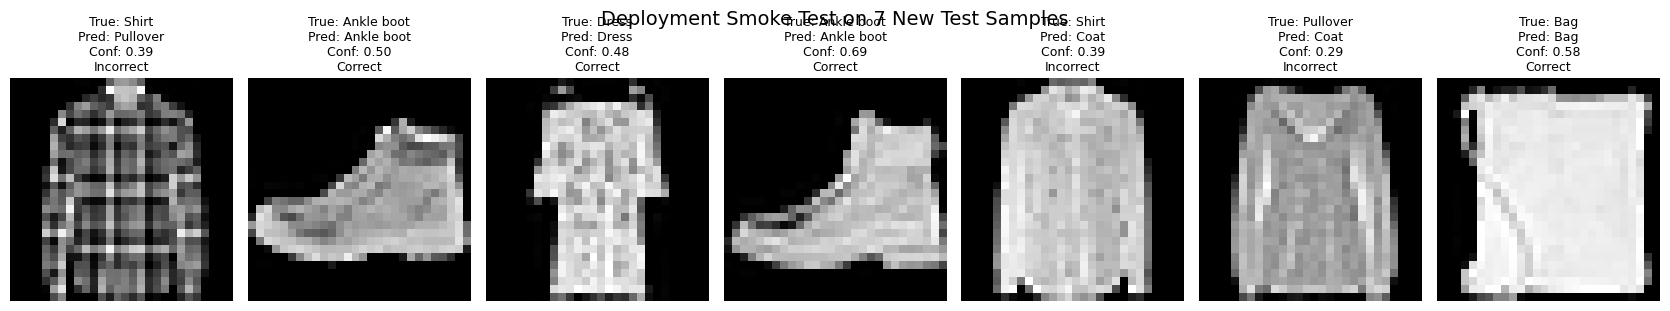


Deployment Smoke Test
Number of test samples       : 7
Smoke test accuracy          : 0.5714
Smoke test CSV saved to      : dcgan_fmnist_research_deployment/outputs/deployment_smoke_test_7_samples.csv
Smoke test figure saved to   : dcgan_fmnist_research_deployment/figures/deployment_smoke_test_7_samples.png
Smoke test summary saved to  : dcgan_fmnist_research_deployment/outputs/deployment_smoke_test_summary.json


,sample_id,true_label_id,true_label_name,predicted_label_id,predicted_label_name,confidence,is_correct
0,0,6,Shirt,2,Pullover,0.392979,False
1,1,9,Ankle boot,9,Ankle boot,0.502684,True
2,2,3,Dress,3,Dress,0.479333,True
3,3,9,Ankle boot,9,Ankle boot,0.686329,True
4,4,6,Shirt,4,Coat,0.394127,False
5,5,2,Pullover,4,Coat,0.290104,False
6,6,8,Bag,8,Bag,0.579057,True


In [14]:
# ============================================================
# Step 10 — Deployment Smoke Test with 7 New Test Samples
# ============================================================
# Deskripsi:
# Cell ini melakukan pengujian sederhana terhadap model classifier evaluator
# menggunakan 7 data baru dari test subset. Tujuan smoke test adalah memastikan
# model dapat melakukan inference, menghasilkan label prediksi, confidence,
# tabel hasil, dan visualisasi yang siap dipakai dalam dashboard Streamlit.
#
# Prinsip integritas:
# 1. Smoke test bukan pengganti evaluasi model utama.
# 2. Data yang digunakan berasal dari test subset, bukan train subset.
# 3. Jumlah sampel kecil hanya untuk validasi deployment sederhana.
# 4. Hasil disimpan sebagai CSV dan gambar agar terdokumentasi.

# ------------------------------------------------------------
# Validasi prasyarat.
# ------------------------------------------------------------

required_step10_objects = [
    "classifier_model",
    "test_norm_subset",
    "test_raw_subset",
    "CLASS_NAMES",
    "CONFIG",
    "DEVICE",
    "OUTPUT_DIR",
    "FIGURE_DIR",
    "MODEL_DIR"
]

missing_step10_objects = [
    name for name in required_step10_objects
    if name not in globals()
]

if len(missing_step10_objects) > 0:
    raise NameError(
        "Objek berikut belum tersedia dari cell sebelumnya: "
        + ", ".join(missing_step10_objects)
        + ". Jalankan Cell 1 sampai Cell 9 secara berurutan terlebih dahulu."
    )

# ------------------------------------------------------------
# Tentukan jumlah sampel smoke test.
# Default adalah 7 sampel sesuai konfigurasi.
# ------------------------------------------------------------

smoke_n = int(CONFIG.get("smoke_test_samples", 7))
smoke_n = min(smoke_n, len(test_norm_subset))

if smoke_n < 5:
    raise ValueError(
        "Jumlah smoke test sample terlalu kecil. "
        "Gunakan minimal 5 sampel untuk validasi deployment sederhana."
    )

# ------------------------------------------------------------
# Ambil 7 data test baru secara deterministic.
# Karena test subset tidak digunakan untuk training classifier,
# data ini relevan untuk pengujian sederhana deployment.
# ------------------------------------------------------------

smoke_indices = np.arange(smoke_n)

smoke_images_norm = []
smoke_images_raw = []
smoke_true_labels = []

for idx in smoke_indices:
    img_norm, label_norm = test_norm_subset[int(idx)]
    img_raw, label_raw = test_raw_subset[int(idx)]

    assert int(label_norm) == int(label_raw), (
        "Label pada test_norm_subset dan test_raw_subset tidak konsisten."
    )

    smoke_images_norm.append(img_norm)
    smoke_images_raw.append(img_raw)
    smoke_true_labels.append(int(label_norm))

smoke_images_norm_tensor = torch.stack(smoke_images_norm, dim=0).to(DEVICE)
smoke_true_labels_np = np.asarray(smoke_true_labels)

# ------------------------------------------------------------
# Inference classifier evaluator.
# Model dibuat eval agar BatchNorm dan Dropout berada pada mode evaluasi.
# ------------------------------------------------------------

classifier_model.eval()

with torch.no_grad():
    smoke_logits = classifier_model(smoke_images_norm_tensor)
    smoke_probabilities = torch.softmax(smoke_logits, dim=1)
    smoke_predictions = torch.argmax(smoke_probabilities, dim=1)
    smoke_confidences = torch.max(smoke_probabilities, dim=1).values

smoke_predictions_np = smoke_predictions.detach().cpu().numpy()
smoke_confidences_np = smoke_confidences.detach().cpu().numpy()

smoke_accuracy = accuracy_score(
    smoke_true_labels_np,
    smoke_predictions_np
)

# ------------------------------------------------------------
# Buat tabel hasil smoke test.
# ------------------------------------------------------------

smoke_test_df = pd.DataFrame({
    "sample_id": smoke_indices,
    "true_label_id": smoke_true_labels_np,
    "true_label_name": [CLASS_NAMES[i] for i in smoke_true_labels_np],
    "predicted_label_id": smoke_predictions_np,
    "predicted_label_name": [CLASS_NAMES[i] for i in smoke_predictions_np],
    "confidence": smoke_confidences_np,
    "is_correct": smoke_true_labels_np == smoke_predictions_np
})

smoke_test_path = OUTPUT_DIR / "deployment_smoke_test_7_samples.csv"
smoke_test_df.to_csv(smoke_test_path, index=False)

# ------------------------------------------------------------
# Visualisasi 7 sampel smoke test.
# Judul output menggunakan Bahasa Inggris.
# ------------------------------------------------------------

cols = smoke_n
fig, axes = plt.subplots(1, cols, figsize=(2.4 * cols, 3.2))

if smoke_n == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    raw_img = smoke_images_raw[i].squeeze(0).detach().cpu().numpy()

    true_name = smoke_test_df.loc[i, "true_label_name"]
    pred_name = smoke_test_df.loc[i, "predicted_label_name"]
    conf_value = smoke_test_df.loc[i, "confidence"]
    correctness = "Correct" if smoke_test_df.loc[i, "is_correct"] else "Incorrect"

    ax.imshow(raw_img, cmap="gray")
    ax.set_title(
        f"True: {true_name}\nPred: {pred_name}\nConf: {conf_value:.2f}\n{correctness}",
        fontsize=9
    )
    ax.axis("off")

fig.suptitle("Deployment Smoke Test on 7 New Test Samples", fontsize=14)

smoke_test_fig_path = FIGURE_DIR / "deployment_smoke_test_7_samples.png"
plt.tight_layout()
plt.savefig(smoke_test_fig_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Simpan metadata smoke test.
# ------------------------------------------------------------

smoke_test_summary = {
    "test_type": "deployment_smoke_test",
    "sample_count": int(smoke_n),
    "smoke_test_accuracy": float(smoke_accuracy),
    "csv_path": str(smoke_test_path),
    "figure_path": str(smoke_test_fig_path),
    "note": (
        "This smoke test verifies basic inference behavior on a small number of unseen test samples. "
        "It should not be interpreted as the full model evaluation result."
    ),
    "created_at": datetime.now().isoformat()
}

smoke_test_summary_path = OUTPUT_DIR / "deployment_smoke_test_summary.json"

with open(smoke_test_summary_path, "w", encoding="utf-8") as f:
    json.dump(smoke_test_summary, f, indent=4, ensure_ascii=False)

# ------------------------------------------------------------
# Ringkasan output.
# ------------------------------------------------------------

print("\nDeployment Smoke Test")
print("=" * 70)
print(f"Number of test samples       : {smoke_n}")
print(f"Smoke test accuracy          : {smoke_accuracy:.4f}")
print(f"Smoke test CSV saved to      : {smoke_test_path}")
print(f"Smoke test figure saved to   : {smoke_test_fig_path}")
print(f"Smoke test summary saved to  : {smoke_test_summary_path}")
print("=" * 70)

display(smoke_test_df)

In [15]:
# ============================================================
# Step 11 — Generate Streamlit Dashboard Application
# ============================================================
# Deskripsi:
# Cell ini membuat aplikasi Streamlit dalam file app.py.
# Dashboard dirancang untuk:
# 1. Menampilkan ringkasan metadata penelitian.
# 2. Menampilkan hasil smoke test 7 data baru.
# 3. Melakukan inference gambar Fashion-MNIST dari upload pengguna.
# 4. Menghasilkan gambar sintetis dari generator DCGAN final.
#
# Prinsip integritas:
# - Dashboard tidak mengklaim model sempurna.
# - Semua metrik dibaca dari file hasil eksperimen.
# - Model dimuat melalui state_dict, bukan dibuat dari klaim manual.
# - Aplikasi hanya memakai artefak yang tersimpan dalam folder proyek.

# ------------------------------------------------------------
# Validasi prasyarat.
# ------------------------------------------------------------

required_step11_objects = [
    "APP_DIR",
    "PROJECT_DIR",
    "MODEL_DIR",
    "OUTPUT_DIR",
    "FIGURE_DIR",
    "CLASS_NAMES",
    "CONFIG"
]

missing_step11_objects = [
    name for name in required_step11_objects
    if name not in globals()
]

if len(missing_step11_objects) > 0:
    raise NameError(
        "Objek berikut belum tersedia dari cell sebelumnya: "
        + ", ".join(missing_step11_objects)
        + ". Jalankan Cell 1 sampai Cell 10 secara berurutan terlebih dahulu."
    )

# ------------------------------------------------------------
# Path file aplikasi.
# ------------------------------------------------------------

streamlit_app_path = APP_DIR / "app.py"
streamlit_requirements_path = APP_DIR / "requirements.txt"

# ------------------------------------------------------------
# Isi file app.py.
# Catatan:
# - Judul output aplikasi menggunakan Bahasa Inggris.
# - Komentar kode menggunakan Bahasa Indonesia akademik.
# - Model PyTorch dimuat dengan state_dict.
# - model.eval() dipakai agar inference konsisten.
# ------------------------------------------------------------

app_code = r'''
# ============================================================
# DCGAN-FMNIST Research Dashboard
# ============================================================
# Deskripsi:
# Aplikasi Streamlit ini menampilkan dashboard interaktif untuk
# artefak penelitian DCGAN Fashion-MNIST. Dashboard mencakup:
# 1. Research summary
# 2. Deployment smoke test
# 3. Image upload inference
# 4. Synthetic image generation
#
# Catatan integritas:
# Aplikasi ini bukan sistem produksi final. Dashboard ini adalah
# prototipe akademik untuk inspeksi model, evaluasi sederhana,
# dan demonstrasi deployment.

import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import streamlit as st

import torch
import torch.nn as nn
import torchvision.utils as vutils
from torchvision import transforms


# ------------------------------------------------------------
# Konfigurasi path.
# Aplikasi dijalankan dari folder streamlit_app, sehingga parent
# directory adalah folder proyek utama.
# ------------------------------------------------------------

APP_DIR = Path(__file__).resolve().parent
PROJECT_DIR = APP_DIR.parent
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"

METADATA_PATH = OUTPUT_DIR / "final_experiment_metadata.json"
SMOKE_TEST_PATH = OUTPUT_DIR / "deployment_smoke_test_7_samples.csv"
SMOKE_TEST_FIGURE_PATH = FIGURE_DIR / "deployment_smoke_test_7_samples.png"
FINAL_CLASSIFIER_PATH = MODEL_DIR / "final_classifier_evaluator_state_dict.pt"
FINAL_GENERATOR_PATH = MODEL_DIR / "final_dcgan_generator_state_dict.pt"

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


# ------------------------------------------------------------
# Definisi arsitektur classifier.
# Arsitektur harus sama dengan model yang digunakan saat training.
# ------------------------------------------------------------

class FashionMNISTClassifier(nn.Module):
    """CNN evaluator untuk klasifikasi Fashion-MNIST."""

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits

    def extract_features(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_extractor(x)
        return torch.flatten(features, start_dim=1)


# ------------------------------------------------------------
# Definisi generator DCGAN.
# Arsitektur harus sama dengan generator saat training.
# ------------------------------------------------------------

class DCGANGenerator(nn.Module):
    """Generator DCGAN untuk citra Fashion-MNIST 28x28 grayscale."""

    def __init__(self, latent_dim: int = 100, channels: int = 1):
        super().__init__()

        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(inplace=True)
        )

        self.generator = nn.Sequential(
            nn.Unflatten(dim=1, unflattened_size=(128, 7, 7)),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        projected = self.project(z)
        return self.generator(projected)


# ------------------------------------------------------------
# Fungsi utilitas.
# ------------------------------------------------------------

def denormalize_image_tensor(x: torch.Tensor) -> torch.Tensor:
    """Mengembalikan citra dari rentang [-1, 1] ke [0, 1]."""
    return torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


def preprocess_uploaded_image(uploaded_image: Image.Image) -> torch.Tensor:
    """
    Mengubah gambar upload menjadi format Fashion-MNIST:
    grayscale, 28x28, tensor, dan normalisasi [-1, 1].
    """
    transform_pipeline = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    return transform_pipeline(uploaded_image).unsqueeze(0)


# ------------------------------------------------------------
# Load metadata.
# st.cache_data dipakai untuk data JSON/CSV agar pembacaan tidak berulang.
# ------------------------------------------------------------

@st.cache_data
def load_metadata():
    if METADATA_PATH.exists():
        with open(METADATA_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


@st.cache_data
def load_smoke_test_table():
    if SMOKE_TEST_PATH.exists():
        return pd.read_csv(SMOKE_TEST_PATH)
    return pd.DataFrame()


# ------------------------------------------------------------
# Load model.
# st.cache_resource dipakai karena model adalah resource global.
# ------------------------------------------------------------

@st.cache_resource
def load_classifier_model():
    checkpoint = torch.load(FINAL_CLASSIFIER_PATH, map_location="cpu")
    model = FashionMNISTClassifier(num_classes=10)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


@st.cache_resource
def load_generator_model():
    checkpoint = torch.load(FINAL_GENERATOR_PATH, map_location="cpu")
    latent_dim = int(checkpoint.get("latent_dim", 100))
    channels = int(checkpoint.get("channels", 1))

    model = DCGANGenerator(latent_dim=latent_dim, channels=channels)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model, latent_dim


# ------------------------------------------------------------
# Page configuration.
# ------------------------------------------------------------

st.set_page_config(
    page_title="DCGAN-FMNIST Research Dashboard",
    page_icon="🧪",
    layout="wide"
)

st.title("DCGAN-FMNIST Research Dashboard")
st.caption(
    "Interactive dashboard for classifier evaluation, DCGAN synthetic image generation, "
    "and lightweight deployment inspection."
)

metadata = load_metadata()

# ------------------------------------------------------------
# Sidebar.
# ------------------------------------------------------------

st.sidebar.title("Navigation")
page = st.sidebar.radio(
    "Select Page",
    [
        "Research Summary",
        "Deployment Smoke Test",
        "Image Upload Inference",
        "Synthetic Image Generator",
        "Integrity Notes"
    ]
)

# ------------------------------------------------------------
# Page 1 — Research Summary.
# ------------------------------------------------------------

if page == "Research Summary":
    st.header("Research Summary")

    if metadata:
        col1, col2, col3 = st.columns(3)

        with col1:
            st.metric(
                "Final Model",
                metadata.get("final_model_name", "unknown")
            )

        with col2:
            final_metrics = metadata.get("final_metrics", {})
            st.metric(
                "Feature-FID",
                round(float(final_metrics.get("feature_fid", 0.0)), 4)
            )

        with col3:
            st.metric(
                "Synthetic Entropy",
                round(float(final_metrics.get("synthetic_entropy", 0.0)), 4)
            )

        st.subheader("Final Metrics")
        st.dataframe(pd.DataFrame([metadata.get("final_metrics", {})]))

        st.subheader("Revision Plan")
        st.json(metadata.get("revision_plan", {}))

        st.subheader("Artifact Paths")
        st.json(metadata.get("artifact_paths", {}))

    else:
        st.warning(
            "Metadata file was not found. Please run the notebook until Step 9."
        )


# ------------------------------------------------------------
# Page 2 — Deployment Smoke Test.
# ------------------------------------------------------------

elif page == "Deployment Smoke Test":
    st.header("Deployment Smoke Test")

    smoke_df = load_smoke_test_table()

    if not smoke_df.empty:
        st.dataframe(smoke_df)

        if SMOKE_TEST_FIGURE_PATH.exists():
            st.image(
                str(SMOKE_TEST_FIGURE_PATH),
                caption="Deployment Smoke Test on 7 New Test Samples"
            )
    else:
        st.warning(
            "Smoke test file was not found. Please run Step 10 in the notebook."
        )


# ------------------------------------------------------------
# Page 3 — Image Upload Inference.
# ------------------------------------------------------------

elif page == "Image Upload Inference":
    st.header("Image Upload Inference")

    st.write(
        "Upload a grayscale or RGB image. The app will convert it to Fashion-MNIST-like "
        "format: grayscale, 28×28 pixels, normalized to [-1, 1]."
    )

    uploaded_file = st.file_uploader(
        "Upload an image",
        type=["png", "jpg", "jpeg"]
    )

    if uploaded_file is not None:
        image = Image.open(uploaded_file).convert("RGB")
        st.image(image, caption="Uploaded Image", width=220)

        input_tensor = preprocess_uploaded_image(image)

        classifier = load_classifier_model()

        with torch.no_grad():
            logits = classifier(input_tensor)
            probabilities = torch.softmax(logits, dim=1).squeeze(0).numpy()

        pred_id = int(np.argmax(probabilities))
        confidence = float(np.max(probabilities))

        st.subheader("Prediction Result")
        st.metric("Predicted Class", CLASS_NAMES[pred_id])
        st.metric("Confidence", f"{confidence:.4f}")

        prob_df = pd.DataFrame({
            "class_name": CLASS_NAMES,
            "probability": probabilities
        }).sort_values("probability", ascending=False)

        st.dataframe(prob_df)

        st.bar_chart(
            prob_df.set_index("class_name")["probability"]
        )

    else:
        st.info("Please upload an image to run inference.")


# ------------------------------------------------------------
# Page 4 — Synthetic Image Generator.
# ------------------------------------------------------------

elif page == "Synthetic Image Generator":
    st.header("Synthetic Image Generator")

    st.write(
        "Generate synthetic Fashion-MNIST-like images from the final DCGAN generator. "
        "The generated images should be interpreted together with the reported metrics."
    )

    sample_count = st.slider(
        "Number of synthetic samples",
        min_value=4,
        max_value=64,
        value=16,
        step=4
    )

    seed_value = st.number_input(
        "Random seed",
        min_value=0,
        max_value=999999,
        value=42,
        step=1
    )

    if st.button("Generate Synthetic Images"):
        generator, latent_dim = load_generator_model()

        torch.manual_seed(int(seed_value))

        with torch.no_grad():
            z = torch.randn(sample_count, latent_dim)
            fake_images = generator(z)
            fake_images = denormalize_image_tensor(fake_images)

        grid = vutils.make_grid(
            fake_images,
            nrow=8,
            padding=2
        )

        grid_np = grid.squeeze(0).permute(1, 2, 0).numpy()

        st.image(
            grid_np,
            caption="Generated Synthetic Fashion-MNIST Images",
            clamp=True
        )


# ------------------------------------------------------------
# Page 5 — Integrity Notes.
# ------------------------------------------------------------

elif page == "Integrity Notes":
    st.header("Integrity Notes")

    st.markdown(
        """
        This dashboard is a research prototype, not a production-grade system.

        **Important interpretation rules:**

        1. DCGAN is a generative model, so classifier accuracy is not DCGAN accuracy.
        2. Synthetic images must be evaluated using visual inspection and distributional metrics.
        3. Feature-FID and Feature-KID are auxiliary indicators and depend on the classifier feature space.
        4. The 7-sample smoke test is only a deployment sanity check, not a full evaluation.
        5. The model artifacts should only be loaded from trusted sources.
        """
    )
'''

# ------------------------------------------------------------
# Tulis app.py.
# ------------------------------------------------------------

with open(streamlit_app_path, "w", encoding="utf-8") as f:
    f.write(app_code)

# ------------------------------------------------------------
# Tulis requirements.txt.
# ------------------------------------------------------------

requirements_text = """
streamlit
pyngrok
torch
torchvision
pandas
numpy
pillow
matplotlib
scikit-learn
scipy
joblib
""".strip()

with open(streamlit_requirements_path, "w", encoding="utf-8") as f:
    f.write(requirements_text)

# ------------------------------------------------------------
# Simpan ringkasan file aplikasi.
# ------------------------------------------------------------

streamlit_generation_summary = {
    "app_path": str(streamlit_app_path),
    "requirements_path": str(streamlit_requirements_path),
    "expected_metadata_path": str(OUTPUT_DIR / "final_experiment_metadata.json"),
    "expected_classifier_path": str(MODEL_DIR / "final_classifier_evaluator_state_dict.pt"),
    "expected_generator_path": str(MODEL_DIR / "final_dcgan_generator_state_dict.pt"),
    "created_at": datetime.now().isoformat()
}

streamlit_generation_summary_path = OUTPUT_DIR / "streamlit_app_generation_summary.json"

with open(streamlit_generation_summary_path, "w", encoding="utf-8") as f:
    json.dump(streamlit_generation_summary, f, indent=4, ensure_ascii=False)

# ------------------------------------------------------------
# Integrity check.
# ------------------------------------------------------------

expected_streamlit_files = [
    streamlit_app_path,
    streamlit_requirements_path,
    streamlit_generation_summary_path
]

missing_streamlit_files = [
    str(path) for path in expected_streamlit_files
    if not Path(path).exists()
]

if len(missing_streamlit_files) > 0:
    raise FileNotFoundError(
        "Beberapa file Streamlit gagal dibuat: "
        + ", ".join(missing_streamlit_files)
    )

print("\nStreamlit Dashboard Application")
print("=" * 70)
print(f"Streamlit app created at          : {streamlit_app_path}")
print(f"Requirements file created at      : {streamlit_requirements_path}")
print(f"Generation summary saved to       : {streamlit_generation_summary_path}")
print("=" * 70)


Streamlit Dashboard Application
Streamlit app created at          : dcgan_fmnist_research_deployment/streamlit_app/app.py
Requirements file created at      : dcgan_fmnist_research_deployment/streamlit_app/requirements.txt
Generation summary saved to       : dcgan_fmnist_research_deployment/outputs/streamlit_app_generation_summary.json


In [17]:
# ============================================================
# Step 12 — Run Streamlit Dashboard with ngrok in Google Colab
# Revised Version: Fix connection refused on port 8501
# ============================================================
# Deskripsi:
# Cell ini menjalankan Streamlit dan baru membuka tunnel ngrok setelah
# port 8501 terbukti aktif. Revisi ini mencegah error:
# "dial tcp [::1]:8501: connect: connection refused".
#
# Prinsip integritas:
# 1. Token ngrok tidak ditulis langsung di kode.
# 2. Token tidak dicetak dan tidak disimpan ke file.
# 3. Log Streamlit dibaca jika server gagal berjalan.
# 4. Tunnel ngrok hanya dibuat setelah Streamlit aktif.

import os
import time
import json
import socket
import signal
import getpass
import subprocess
from pathlib import Path
from datetime import datetime

from pyngrok import ngrok, conf

# ------------------------------------------------------------
# Validasi prasyarat.
# ------------------------------------------------------------

required_step12_objects = [
    "APP_DIR",
    "PROJECT_DIR",
    "OUTPUT_DIR",
    "streamlit_app_path"
]

missing_step12_objects = [
    name for name in required_step12_objects
    if name not in globals()
]

if len(missing_step12_objects) > 0:
    raise NameError(
        "Objek berikut belum tersedia dari cell sebelumnya: "
        + ", ".join(missing_step12_objects)
        + ". Jalankan Cell 1 sampai Cell 11 secara berurutan terlebih dahulu."
    )

APP_DIR = Path(APP_DIR)
PROJECT_DIR = Path(PROJECT_DIR)
OUTPUT_DIR = Path(OUTPUT_DIR)
streamlit_app_path = Path(streamlit_app_path)

if not streamlit_app_path.exists():
    raise FileNotFoundError(
        f"File Streamlit app tidak ditemukan: {streamlit_app_path}. "
        "Jalankan Cell 11 terlebih dahulu."
    )

STREAMLIT_PORT = 8501
streamlit_log_path = OUTPUT_DIR / "streamlit_runtime.log"

# ------------------------------------------------------------
# Fungsi cek apakah port sudah aktif.
# ------------------------------------------------------------

def is_port_open(host: str = "127.0.0.1", port: int = 8501, timeout: float = 1.0) -> bool:
    """Memeriksa apakah server lokal sudah listening pada port tertentu."""
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except OSError:
        return False


# ------------------------------------------------------------
# Fungsi membaca log Streamlit.
# ------------------------------------------------------------

def read_streamlit_log(log_path: Path, tail_lines: int = 80) -> str:
    """Membaca bagian akhir log Streamlit untuk diagnosis error."""
    if not log_path.exists():
        return "Streamlit log file belum tersedia."

    try:
        lines = log_path.read_text(encoding="utf-8", errors="replace").splitlines()
        return "\n".join(lines[-tail_lines:])
    except Exception as error:
        return f"Gagal membaca log Streamlit: {error}"


# ------------------------------------------------------------
# Hentikan proses Streamlit lama jika ada.
# ------------------------------------------------------------

def stop_existing_streamlit_processes() -> None:
    """Menghentikan proses Streamlit lama agar tidak konflik port."""
    try:
        result = subprocess.run(
            ["pgrep", "-f", "streamlit"],
            capture_output=True,
            text=True
        )

        if result.returncode == 0 and result.stdout.strip():
            process_ids = result.stdout.strip().splitlines()

            for pid in process_ids:
                try:
                    os.kill(int(pid), signal.SIGTERM)
                except ProcessLookupError:
                    pass
                except PermissionError:
                    pass

            time.sleep(2)

    except Exception as error:
        print(f"Warning: pengecekan proses Streamlit dilewati. Reason: {error}")


stop_existing_streamlit_processes()

# ------------------------------------------------------------
# Tutup tunnel ngrok lama jika ada.
# ------------------------------------------------------------

try:
    ngrok.kill()
except Exception:
    pass

# ------------------------------------------------------------
# Masukkan token ngrok secara manual dan tersembunyi.
# ------------------------------------------------------------

print("ngrok Authentication")
print("=" * 50)
print("Masukkan ngrok authtoken secara manual.")
print("Token tidak akan ditampilkan dan tidak akan disimpan ke file.")
print("=" * 50)

ngrok_token = getpass.getpass("Enter ngrok authtoken: ")

if not ngrok_token.strip():
    raise ValueError("ngrok authtoken kosong. Masukkan token valid dari dashboard ngrok.")

conf.get_default().auth_token = ngrok_token
del ngrok_token

# ------------------------------------------------------------
# Jalankan Streamlit dari APP_DIR.
# Ini penting agar path relatif di app.py berjalan benar.
# ------------------------------------------------------------

streamlit_command = [
    "streamlit",
    "run",
    "app.py",
    "--server.port",
    str(STREAMLIT_PORT),
    "--server.address",
    "0.0.0.0",
    "--server.headless",
    "true",
    "--browser.gatherUsageStats",
    "false"
]

log_file_handle = open(streamlit_log_path, "w", encoding="utf-8")

streamlit_process = subprocess.Popen(
    streamlit_command,
    stdout=log_file_handle,
    stderr=subprocess.STDOUT,
    cwd=str(APP_DIR)
)

# ------------------------------------------------------------
# Tunggu sampai port Streamlit benar-benar aktif.
# Jangan buka ngrok sebelum port aktif.
# ------------------------------------------------------------

max_wait_seconds = 60
start_time = time.time()
server_ready = False

while time.time() - start_time < max_wait_seconds:
    # Jika proses mati lebih awal, baca log dan hentikan dengan error informatif.
    if streamlit_process.poll() is not None:
        log_file_handle.close()
        log_tail = read_streamlit_log(streamlit_log_path)
        raise RuntimeError(
            "Streamlit process stopped before opening port 8501.\n\n"
            "Streamlit log tail:\n"
            + log_tail
        )

    if is_port_open("127.0.0.1", STREAMLIT_PORT):
        server_ready = True
        break

    time.sleep(1)

if not server_ready:
    log_file_handle.close()
    log_tail = read_streamlit_log(streamlit_log_path)
    raise TimeoutError(
        "Streamlit server belum aktif pada port 8501 setelah 60 detik.\n\n"
        "Kemungkinan penyebab:\n"
        "1. app.py crash saat startup.\n"
        "2. file model/metadata belum ditemukan.\n"
        "3. port 8501 digunakan proses lain.\n"
        "4. Streamlit belum selesai loading model.\n\n"
        "Streamlit log tail:\n"
        + log_tail
    )

print("Streamlit server is running on port 8501.")

# ------------------------------------------------------------
# Buka tunnel ngrok setelah Streamlit siap.
# ------------------------------------------------------------

public_url = ngrok.connect(
    addr=STREAMLIT_PORT,
    proto="http"
)

public_url_str = public_url.public_url

# ------------------------------------------------------------
# Simpan ringkasan runtime tanpa token.
# ------------------------------------------------------------

streamlit_runtime_summary = {
    "streamlit_port": STREAMLIT_PORT,
    "public_url": public_url_str,
    "app_path": str(streamlit_app_path),
    "runtime_log_path": str(streamlit_log_path),
    "note": (
        "ngrok token was entered manually through getpass and was not stored "
        "in this summary file."
    ),
    "created_at": datetime.now().isoformat()
}

streamlit_runtime_summary_path = OUTPUT_DIR / "streamlit_runtime_summary.json"

with open(streamlit_runtime_summary_path, "w", encoding="utf-8") as f:
    json.dump(streamlit_runtime_summary, f, indent=4, ensure_ascii=False)

print("\nStreamlit Dashboard Public URL")
print("=" * 70)
print(f"Dashboard URL                : {public_url_str}")
print(f"Streamlit runtime log        : {streamlit_log_path}")
print(f"Runtime summary saved to     : {streamlit_runtime_summary_path}")
print("=" * 70)
print("Catatan: URL bersifat sementara selama runtime Colab aktif.")

ngrok Authentication
Masukkan ngrok authtoken secara manual.
Token tidak akan ditampilkan dan tidak akan disimpan ke file.
Enter ngrok authtoken: ··········
Streamlit server is running on port 8501.

Streamlit Dashboard Public URL
Dashboard URL                : https://edginess-reunion-marshland.ngrok-free.dev
Streamlit runtime log        : dcgan_fmnist_research_deployment/outputs/streamlit_runtime.log
Runtime summary saved to     : dcgan_fmnist_research_deployment/outputs/streamlit_runtime_summary.json
Catatan: URL bersifat sementara selama runtime Colab aktif.


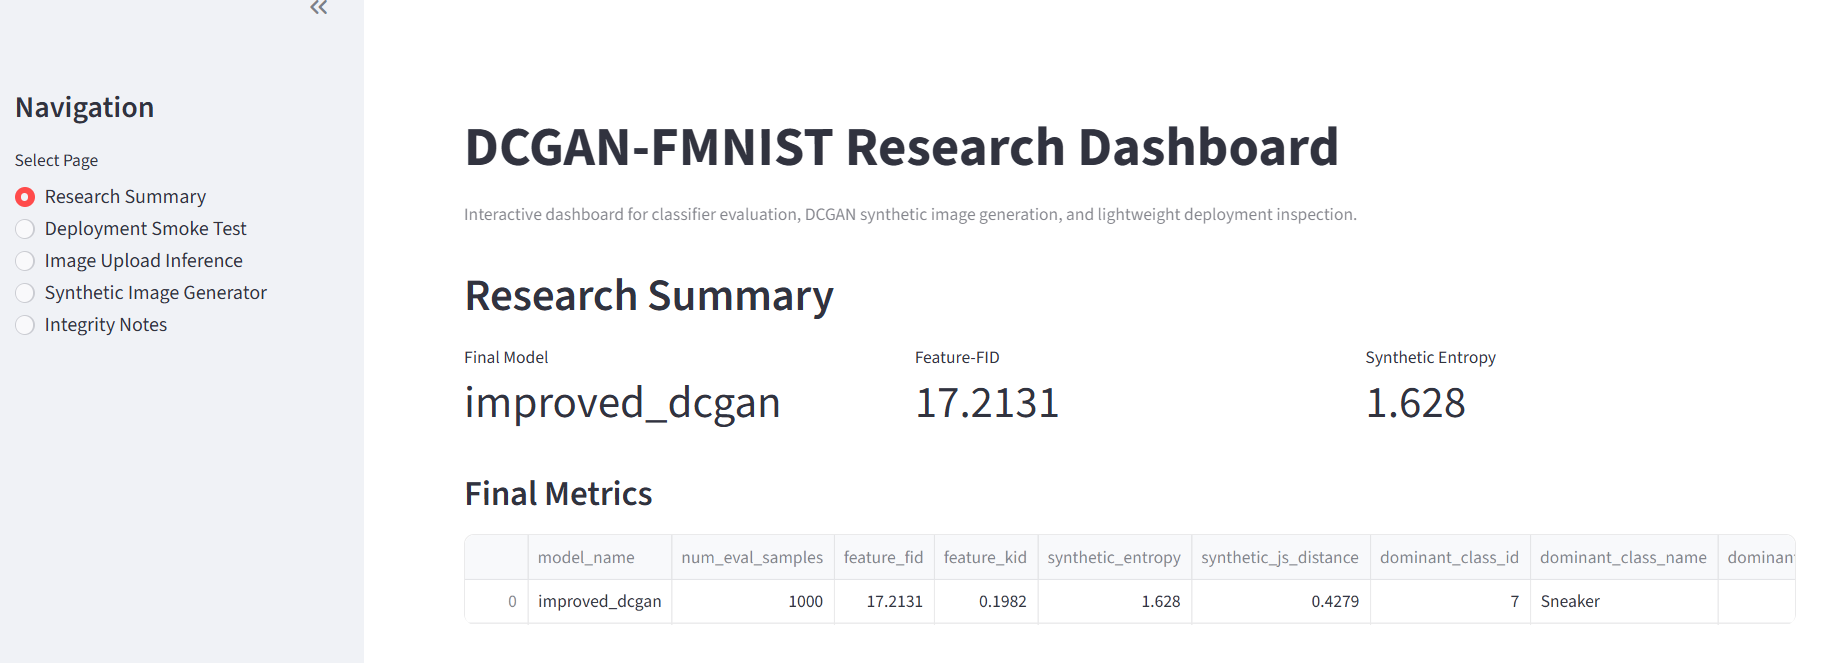

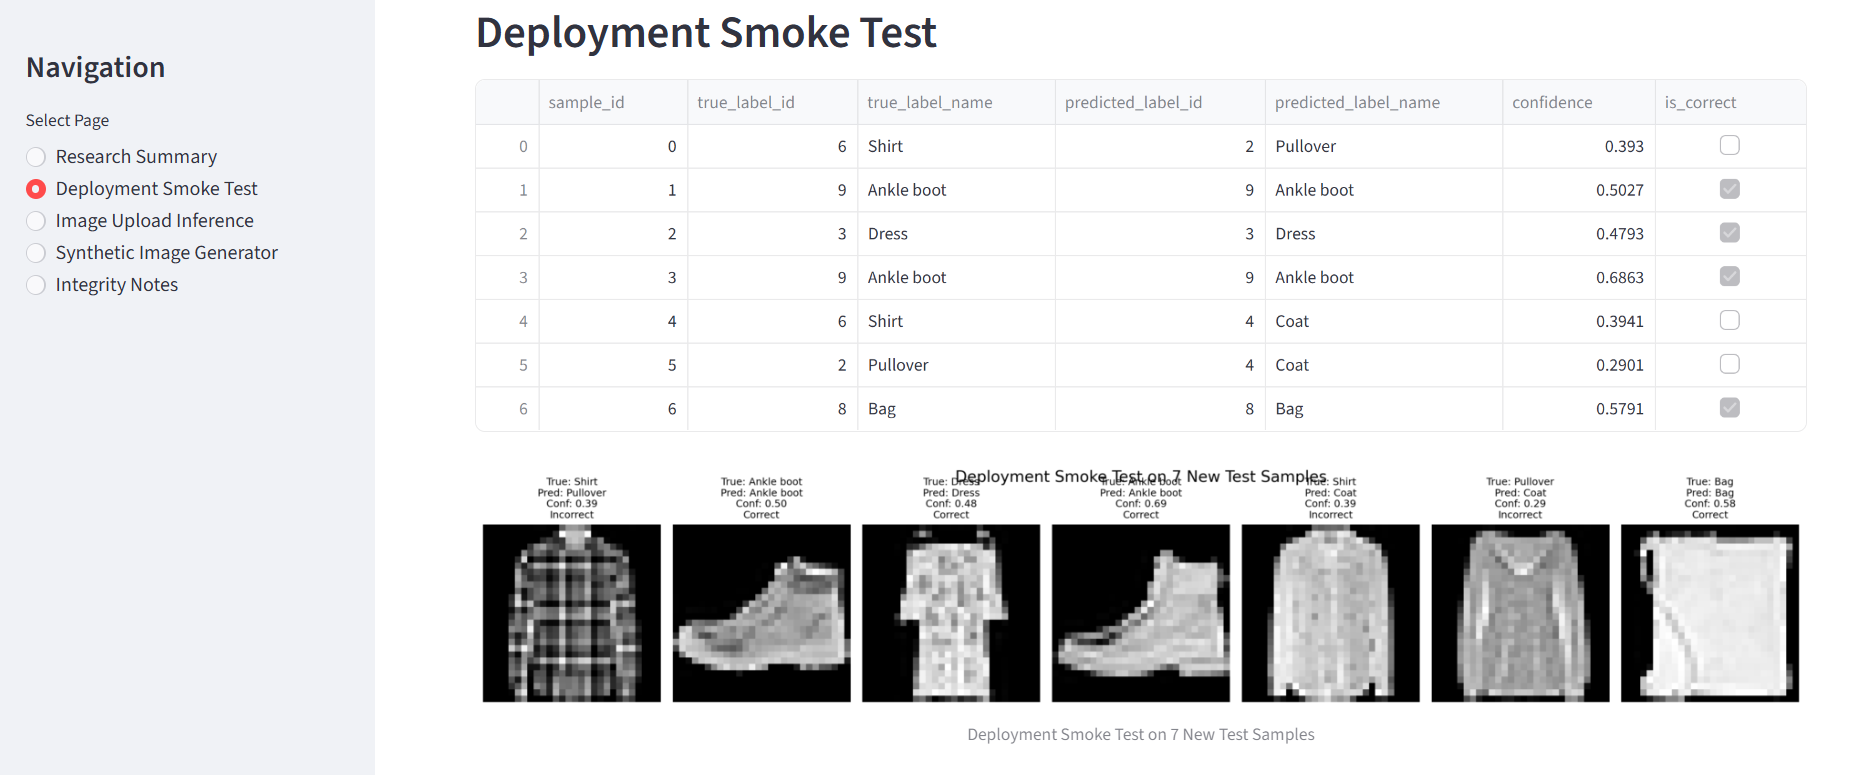

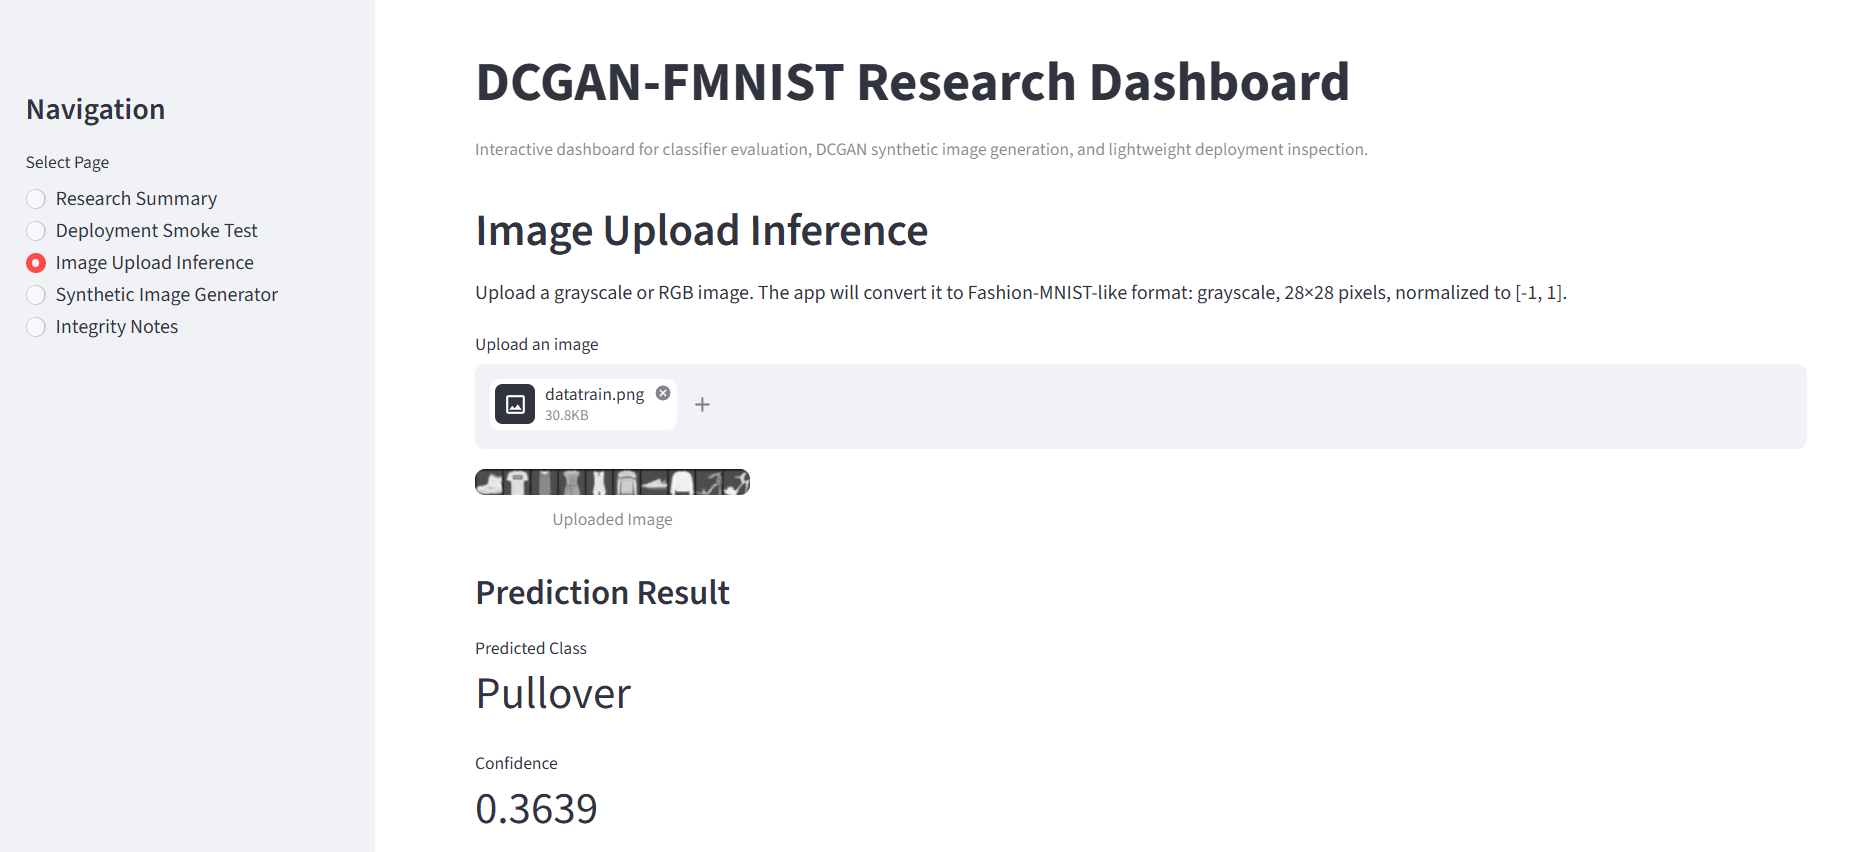

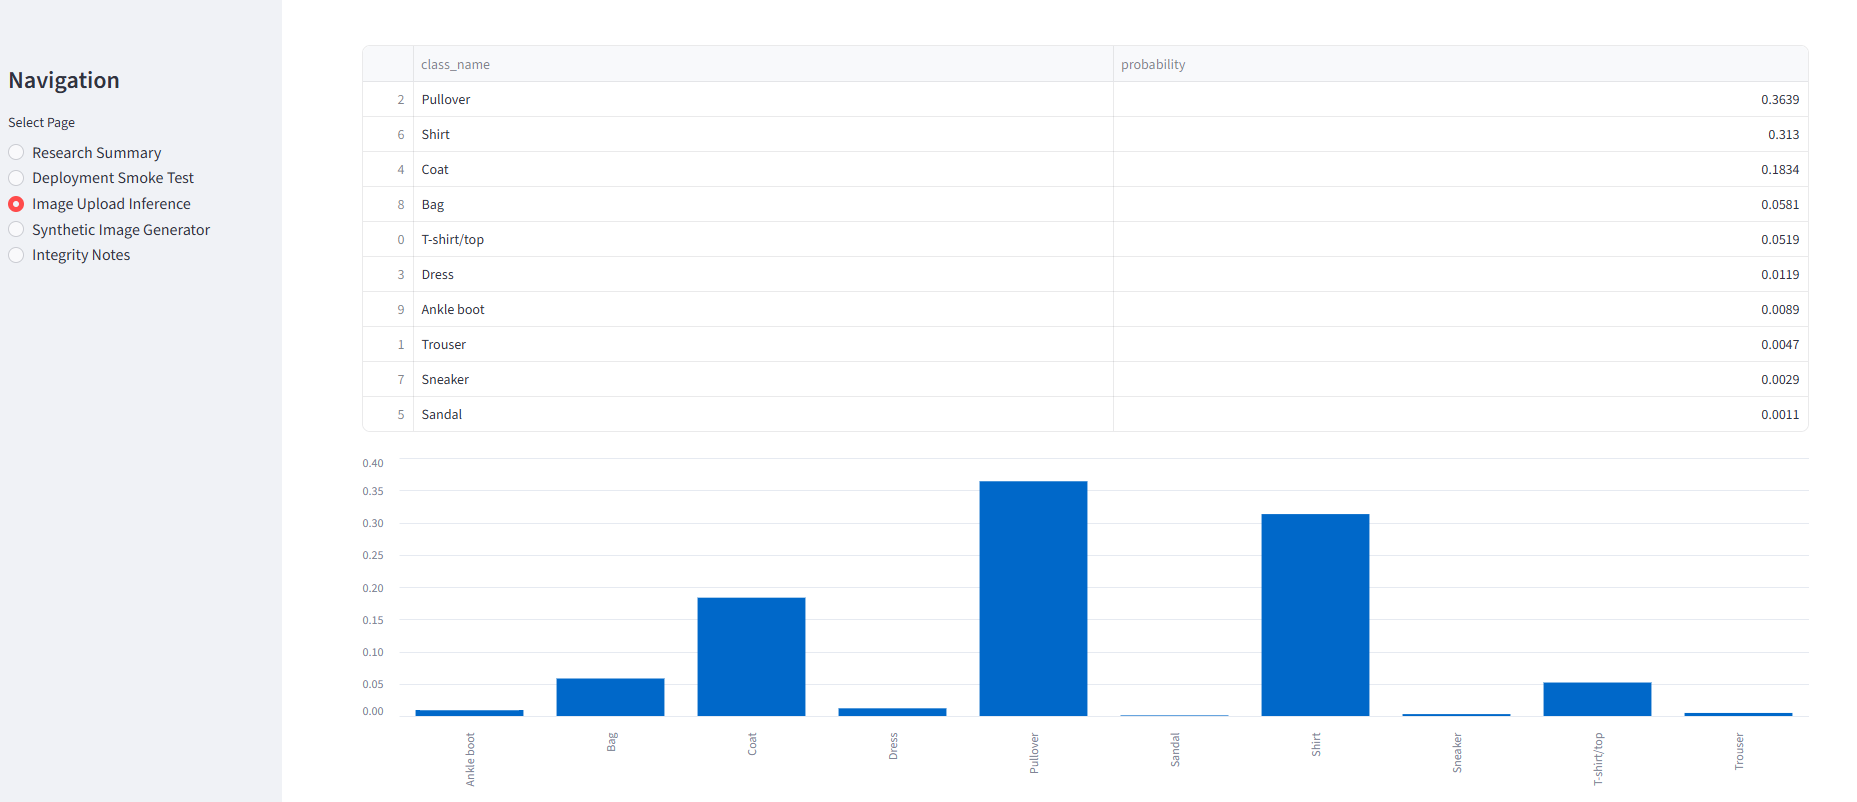

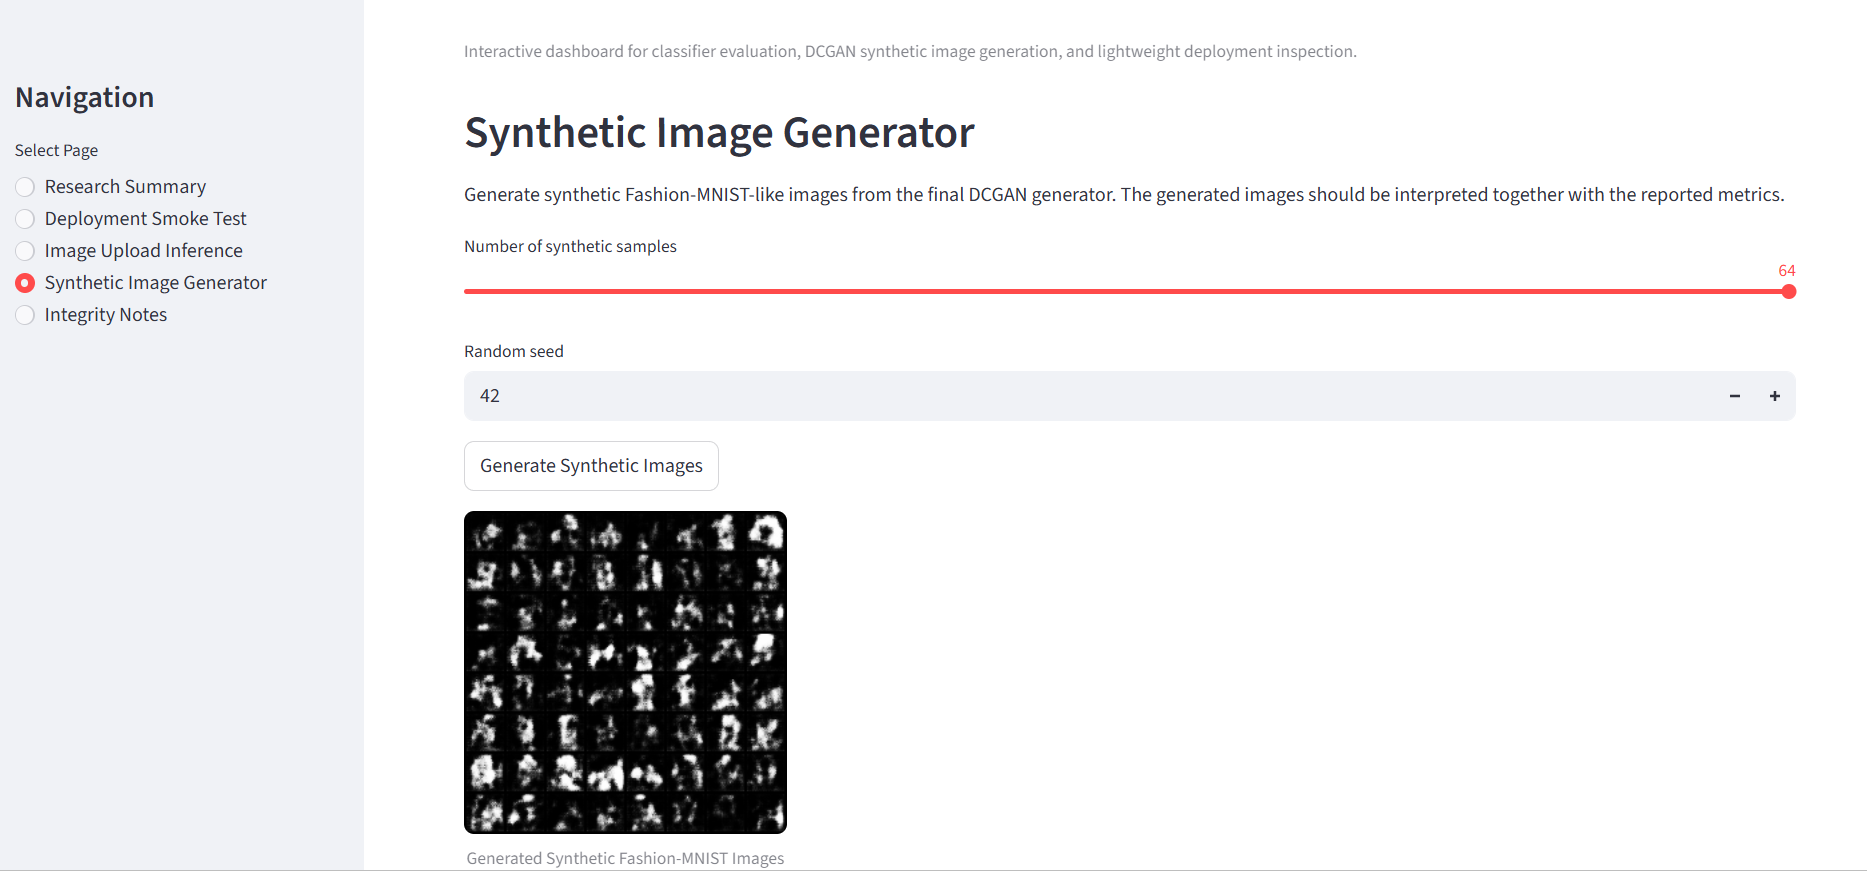

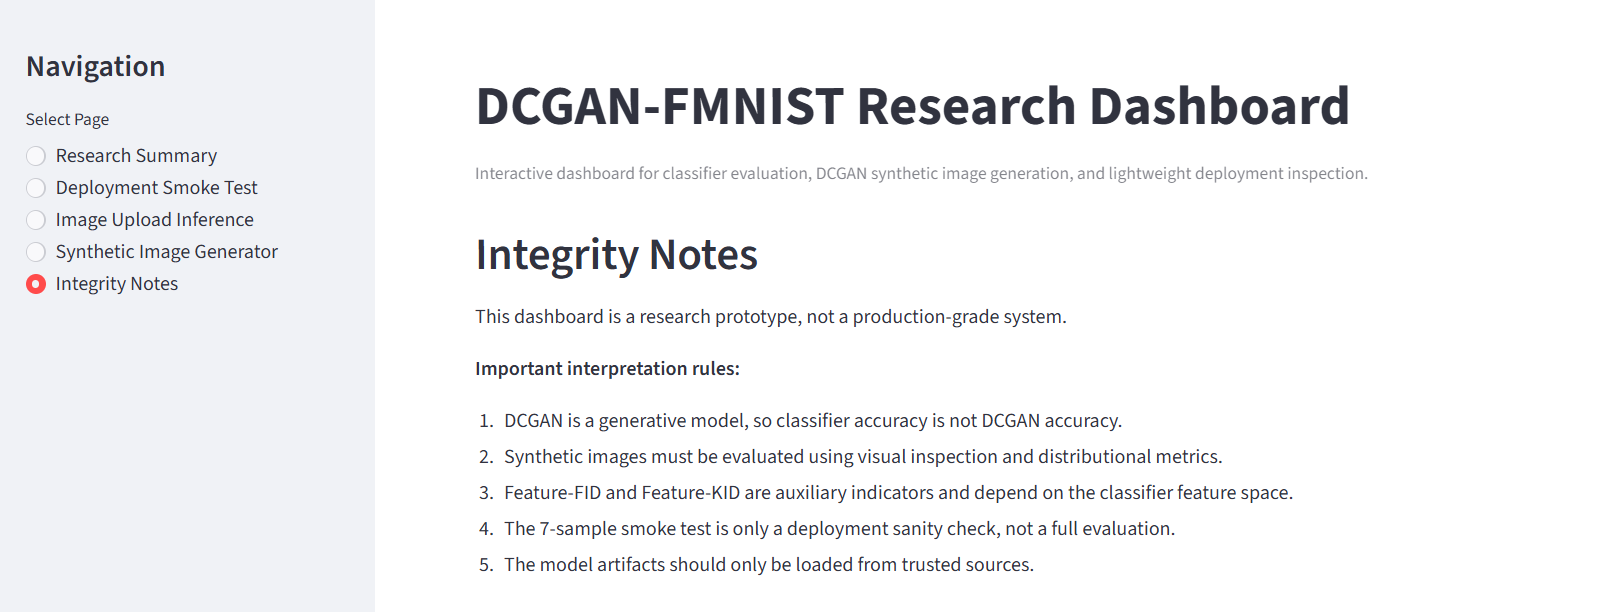

In [19]:
# ============================================================
# Step 13 — Final Research Report and Project Package
# Revised Version: Safe Markdown Builder without Long f-string
# ============================================================
# Deskripsi:
# Cell ini membuat laporan akhir penelitian dan ZIP package.
# Versi revisi ini tidak memakai f-string triple-quoted panjang
# agar terhindar dari SyntaxError: incomplete input.

import os
import json
import zipfile
from pathlib import Path
from datetime import datetime

# ------------------------------------------------------------
# Validasi prasyarat.
# ------------------------------------------------------------

required_step13_objects = [
    "PROJECT_DIR",
    "OUTPUT_DIR",
    "FIGURE_DIR",
    "MODEL_DIR",
    "REPORT_DIR",
    "APP_DIR",
    "CONFIG",
    "CLASS_NAMES"
]

missing_step13_objects = [
    name for name in required_step13_objects
    if name not in globals()
]

if len(missing_step13_objects) > 0:
    raise NameError(
        "Objek berikut belum tersedia dari cell sebelumnya: "
        + ", ".join(missing_step13_objects)
        + ". Jalankan Cell 1 sampai Cell 12 secara berurutan terlebih dahulu."
    )

PROJECT_DIR = Path(PROJECT_DIR)
OUTPUT_DIR = Path(OUTPUT_DIR)
FIGURE_DIR = Path(FIGURE_DIR)
MODEL_DIR = Path(MODEL_DIR)
REPORT_DIR = Path(REPORT_DIR)
APP_DIR = Path(APP_DIR)

REPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load metadata final.
# Metadata ini dibuat pada Step 9.
# ------------------------------------------------------------

metadata_json_path = OUTPUT_DIR / "final_experiment_metadata.json"

if not metadata_json_path.exists():
    raise FileNotFoundError(
        f"Metadata final tidak ditemukan: {metadata_json_path}. "
        "Jalankan ulang Step 9 terlebih dahulu."
    )

with open(metadata_json_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

final_metrics = metadata.get("final_metrics", {})
baseline_metrics = metadata.get("baseline_metrics", {})
improved_metrics = metadata.get("improved_metrics", {})
revision_plan = metadata.get("revision_plan", {})
final_model_name = metadata.get("final_model_name", "unknown")

# ------------------------------------------------------------
# Fungsi bantu agar metrik dibaca aman tanpa membuat nilai palsu.
# ------------------------------------------------------------

def safe_metric(metric_dict: dict, key: str, default="N/A"):
    """Mengambil metrik secara aman tanpa membuat nilai palsu."""
    value = metric_dict.get(key, default)

    if isinstance(value, float):
        return round(value, 6)

    return value


def metric_table(metric_dict: dict, model_label: str) -> list:
    """Membuat tabel Markdown metrik generatif."""
    return [
        f"## {model_label}",
        "",
        "| Metric | Value |",
        "|---|---:|",
        f"| Feature-FID | {safe_metric(metric_dict, 'feature_fid')} |",
        f"| Feature-KID | {safe_metric(metric_dict, 'feature_kid')} |",
        f"| Synthetic Entropy | {safe_metric(metric_dict, 'synthetic_entropy')} |",
        f"| Synthetic JS Distance | {safe_metric(metric_dict, 'synthetic_js_distance')} |",
        f"| Dominant Class | {safe_metric(metric_dict, 'dominant_class_name')} |",
        f"| Dominant Class Probability | {safe_metric(metric_dict, 'dominant_class_probability')} |",
        f"| Mean Fake Classifier Confidence | {safe_metric(metric_dict, 'mean_fake_classifier_confidence')} |",
        f"| Nearest-Neighbor Mean Distance | {safe_metric(metric_dict, 'nearest_neighbor_distance_mean')} |",
        f"| Mode Collapse Flag | {safe_metric(metric_dict, 'mode_collapse_flag')} |",
        ""
    ]


# ------------------------------------------------------------
# Buat laporan Markdown dengan list of lines.
# Pendekatan ini lebih aman dibanding f-string triple-quoted panjang.
# ------------------------------------------------------------

report_created_at = datetime.now().isoformat()
revision_plan_json = json.dumps(revision_plan, indent=2, ensure_ascii=False)

report_lines = []

report_lines.extend([
    "# DCGAN-FMNIST Research and Deployment Report",
    "",
    f"**Created at:** {report_created_at}",
    f"**Final selected model:** `{final_model_name}`",
    f"**Data fraction:** `{CONFIG.get('data_fraction', 'N/A')}`",
    f"**Seed:** `{CONFIG.get('seed', 'N/A')}`",
    "",
    "---",
    "",
    "## Abstract",
    "",
    (
        "Penelitian ini mengembangkan pipeline eksperimen DCGAN pada Fashion-MNIST "
        "dengan fokus pada integritas metodologis, reproducibility, bias diagnostics, "
        "evaluasi generatif terpadu, dan deployment sederhana berbasis Streamlit."
    ),
    "",
    "## Research Objective",
    "",
    (
        "Tujuan utama penelitian ini adalah membangun dan mengevaluasi DCGAN pada "
        "Fashion-MNIST secara bertahap, terukur, dan dapat direproduksi. Pipeline ini "
        "tidak diarahkan untuk membuat klaim keberhasilan sepihak, tetapi menyediakan "
        "mekanisme audit ilmiah terhadap kualitas, keberagaman, dan stabilitas hasil generatif."
    ),
    "",
    "## Dataset and Experimental Scope",
    "",
    (
        f"Dataset yang digunakan adalah Fashion-MNIST. Untuk meringankan komputasi, "
        f"eksperimen prototipe memakai subset stratified sebesar "
        f"`{CONFIG.get('data_fraction', 'N/A')}` dari data keseluruhan."
    ),
    "",
    (
        "Catatan integritas: hasil dari subset 10% harus diperlakukan sebagai eksperimen "
        "ringan. Untuk laporan publikasi final, eksperimen sebaiknya dijalankan ulang pada "
        "data penuh dan jumlah epoch lebih besar."
    ),
    "",
    "## Methodology",
    "",
    "Tahapan penelitian yang dijalankan:",
    "",
    "1. Project initialization and reproducibility configuration.",
    "2. Automatic dataset loading with stratified 10% subset.",
    "3. Exploratory Data Analysis and bias diagnostics.",
    "4. DataLoader construction with imbalance prevention.",
    "5. Classifier evaluator training and evaluation.",
    "6. Baseline DCGAN training.",
    "7. Integrated generative evaluation.",
    "8. Logical revision with Improved DCGAN.",
    "9. Final model artifact saving.",
    "10. Deployment smoke test using 7 unseen test samples.",
    "11. Streamlit dashboard generation.",
    "12. ngrok-based dashboard access.",
    "13. Final report and project packaging.",
    ""
])

report_lines.extend(metric_table(baseline_metrics, "Baseline DCGAN Metrics"))
report_lines.extend(metric_table(improved_metrics, "Improved DCGAN Metrics"))
report_lines.extend(metric_table(final_metrics, "Final Selected Model Metrics"))

report_lines.extend([
    "## Logical Revision Summary",
    "",
    "Strategi revisi yang digunakan:",
    "",
    "```json",
    revision_plan_json,
    "```",
    "",
    (
        "Revisi model dilakukan secara logis berdasarkan evaluasi baseline. Jika indikator "
        "mode collapse, entropy rendah, atau dominasi satu kelas terdeteksi, maka Improved "
        "DCGAN menjalankan stabilisasi berupa label smoothing, instance noise, dan TTUR ringan."
    ),
    "",
    "## Deployment Smoke Test",
    "",
    (
        "Smoke test dilakukan pada 7 data baru dari test subset. Tujuannya adalah memastikan "
        "model classifier evaluator dapat melakukan inference pada sampel baru dan menghasilkan "
        "output yang dapat ditampilkan pada dashboard Streamlit."
    ),
    "",
    (
        "Catatan penting: smoke test bukan pengganti evaluasi penuh. Hasil ini hanya menunjukkan "
        "kesiapan teknis awal untuk deployment sederhana."
    ),
    "",
    "## Streamlit Dashboard",
    "",
    "Dashboard Streamlit dibuat sebagai prototipe akademik untuk:",
    "",
    "1. menampilkan research summary,",
    "2. menampilkan deployment smoke test,",
    "3. melakukan image upload inference,",
    "4. menghasilkan synthetic image dari generator final,",
    "5. menampilkan integrity notes.",
    "",
    "Token ngrok dimasukkan manual melalui `getpass` dan tidak disimpan ke file proyek.",
    "",
    "## Reproducibility Statement",
    "",
    (
        "Eksperimen dikontrol menggunakan seed Python, NumPy, PyTorch, CUDA, deterministic "
        "setting, cache indeks subset stratified, konfigurasi JSON, dan penyimpanan artefak "
        "dalam satu folder proyek. Meskipun demikian, hasil GPU dapat memiliki variasi kecil "
        "antar perangkat, versi library, dan backend komputasi."
    ),
    "",
    "## Limitations",
    "",
    "1. Eksperimen prototipe menggunakan 10% data untuk efisiensi komputasi.",
    "2. Jumlah epoch dibuat ringan agar dapat dijalankan pada Google Colab.",
    "3. Feature-FID dan Feature-KID dihitung dari feature space classifier evaluator, bukan Inception feature space.",
    "4. Smoke test 7 sampel hanya validasi deployment sederhana, bukan evaluasi statistik penuh.",
    "5. DCGAN baseline tidak diklaim sebagai arsitektur generatif terbaik.",
    "6. Hasil harus ditafsirkan bersama visualisasi, metrik distribusional, dan konteks eksperimen.",
    "",
    "## Data and Code Availability",
    "",
    "Seluruh artefak eksperimen disimpan dalam folder:",
    "",
    "```text",
    str(PROJECT_DIR),
    "```",
    "",
    (
        "Folder ini mencakup dataset cache, konfigurasi, model, grafik, tabel, laporan, "
        "metadata, Streamlit app, dan ZIP package."
    ),
    "",
    "## Conclusion",
    "",
    (
        "Pipeline ini menyediakan kerangka kerja penelitian yang terstruktur untuk implementasi "
        "DCGAN pada Fashion-MNIST dengan penekanan pada integritas, reproducibility, evaluasi "
        "terpadu, dan deployment sederhana. Kekuatan utama pipeline ini bukan hanya pada kemampuan "
        "menghasilkan citra sintetis, tetapi pada mekanisme audit yang membantu menghindari klaim "
        "palsu, bias interpretasi, dan kesimpulan yang hanya bergantung pada loss adversarial."
    ),
    ""
])

final_report_text = "\n".join(report_lines)

final_report_path = REPORT_DIR / "final_research_report.md"

with open(final_report_path, "w", encoding="utf-8") as f:
    f.write(final_report_text)

# ------------------------------------------------------------
# Buat indeks seluruh artefak proyek.
# ------------------------------------------------------------

project_files = []

for file_path in PROJECT_DIR.rglob("*"):
    if file_path.is_file():
        project_files.append({
            "file_name": file_path.name,
            "relative_path": str(file_path.relative_to(PROJECT_DIR)),
            "file_size_kb": round(file_path.stat().st_size / 1024, 3)
        })

project_file_index_df = pd.DataFrame(project_files).sort_values("relative_path")

project_file_index_path = OUTPUT_DIR / "project_file_index.csv"
project_file_index_df.to_csv(project_file_index_path, index=False)

# ------------------------------------------------------------
# Buat ZIP package seluruh folder proyek.
# ------------------------------------------------------------

zip_package_path = Path(f"{PROJECT_DIR.name}_package.zip")

if zip_package_path.exists():
    zip_package_path.unlink()

with zipfile.ZipFile(zip_package_path, mode="w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file_path in PROJECT_DIR.rglob("*"):
        if file_path.is_file():
            arcname = file_path.relative_to(PROJECT_DIR.parent)
            zipf.write(file_path, arcname=arcname)

# ------------------------------------------------------------
# Validasi ZIP.
# ------------------------------------------------------------

if not zip_package_path.exists():
    raise FileNotFoundError("ZIP package gagal dibuat.")

if zip_package_path.stat().st_size == 0:
    raise ValueError("ZIP package berhasil dibuat tetapi ukurannya 0 byte.")

# ------------------------------------------------------------
# Simpan ringkasan final.
# ------------------------------------------------------------

final_package_summary = {
    "final_report_path": str(final_report_path),
    "project_file_index_path": str(project_file_index_path),
    "zip_package_path": str(zip_package_path),
    "zip_size_mb": round(zip_package_path.stat().st_size / (1024 * 1024), 4),
    "total_project_files": int(len(project_file_index_df)),
    "final_model_name": final_model_name,
    "created_at": datetime.now().isoformat()
}

final_package_summary_path = OUTPUT_DIR / "final_package_summary.json"

with open(final_package_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_package_summary, f, indent=4, ensure_ascii=False)

print("\nFinal Research Report and Project Package")
print("=" * 70)
print(f"Final report saved to        : {final_report_path}")
print(f"Project file index saved to  : {project_file_index_path}")
print(f"ZIP package saved to         : {zip_package_path}")
print(f"ZIP package size             : {final_package_summary['zip_size_mb']} MB")
print(f"Total project files          : {final_package_summary['total_project_files']}")
print("=" * 70)

display(pd.DataFrame([final_package_summary]))
display(project_file_index_df.head(30))


Final Research Report and Project Package
Final report saved to        : dcgan_fmnist_research_deployment/reports/final_research_report.md
Project file index saved to  : dcgan_fmnist_research_deployment/outputs/project_file_index.csv
ZIP package saved to         : dcgan_fmnist_research_deployment_package.zip
ZIP package size             : 74.7421 MB
Total project files          : 73


,final_report_path,project_file_index_path,zip_package_path,zip_size_mb,total_project_files,final_model_name,created_at
0,dcgan_fmnist_research_deployment/reports/final...,dcgan_fmnist_research_deployment/outputs/proje...,dcgan_fmnist_research_deployment_package.zip,74.7421,73,improved_dcgan,2026-05-05T10:24:12.690961


,file_name,relative_path,file_size_kb
70,t10k-images-idx3-ubyte,data/FashionMNIST/raw/t10k-images-idx3-ubyte,7656.266
66,t10k-images-idx3-ubyte.gz,data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz,4318.459
65,t10k-labels-idx1-ubyte,data/FashionMNIST/raw/t10k-labels-idx1-ubyte,9.773
71,t10k-labels-idx1-ubyte.gz,data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz,5.027
68,train-images-idx3-ubyte,data/FashionMNIST/raw/train-images-idx3-ubyte,45937.516
72,train-images-idx3-ubyte.gz,data/FashionMNIST/raw/train-images-idx3-ubyte.gz,25802.617
67,train-labels-idx1-ubyte,data/FashionMNIST/raw/train-labels-idx1-ubyte,58.602
69,train-labels-idx1-ubyte.gz,data/FashionMNIST/raw/train-labels-idx1-ubyte.gz,28.823
12,baseline_dcgan_nearest_neighbor_check.png,figures/baseline_dcgan_nearest_neighbor_check.png,145.649
3,baseline_dcgan_synthetic_class_distribution.png,figures/baseline_dcgan_synthetic_class_distrib...,91.711
